### Small Population GFS sampling paper plot

In [51]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [52]:
import numpy as np
import matplotlib.pyplot as plt
import graphical_sampling as gs
from graphical_sampling.index import Moran

In [53]:
# --- Population ---
coords_data = np.array([
    (1,1),(1,2),(1,3),
    (2,1),(2,2),(2,3),
    (3,1),(3,2),(3,3)
])

inclusions_data = np.array([0.7, 0.3, 0.4, 0.8, 0.3, 0.65, 0.45, 0.2, 0.2])
# inclusions_data = np.repeat(3/9,9)
n = int(inclusions_data.sum())

pop = gs.Population(coords_data, inclusions_data, n=n, variable=inclusions_data)

# --- Clustering ---
fbn = gs.clustering.FIPBalancedNMeans(
    n=n,
    centroid_grid_x=1,
    r_sample_per_cluster=1,
    init_clust_method='expanded',
    split_size=.001
)

fbn.fit(pop)
fbn.fit_zones(num_zones=(1,1), mode='sweep_yx')

# --- Order & Design ---
order = gs.Order.from_clusters(
    pop,
    fbn.clusters,
    zone_strategy='lexico_yx',
    point_strategy='lexico_yx',
    num_splits=1,
    topological=True
)

design = gs.Design.from_order(pop, order)


Sample: [1 2 5 7]
Moran(sample): -0.04884546538564359


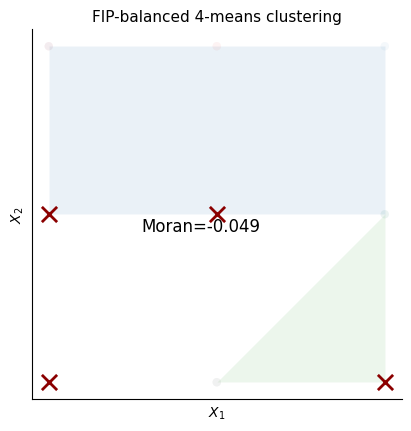

In [ ]:

# =========================================================
# 🔴 STEP 1: draw ONE sample from the design
# =========================================================
sample = design.sample(1)[0]
sample = np.array([1,2,5,7]) -1  # shape (n,)
p
￼
    \textbf{Response:} 
￼
    % YOUR RESPONSE HERE
rint("Sample:", sample+1)

# =========================================================
# 🔴 STEP 2: Moran for THIS sample (not expected value)
# =========================================================
moran_index = Moran(pop, method="tille")
moran_val = moran_index.score(np.array([sample]))[0]

print("Moran(sample):", moran_val)

# =========================================================
# 🔴 STEP 3: Plot
# =========================================================
fig, ax = plt.subplots()

# background clusters
fbn.plot(mode='soft', ax=ax)

coords = pop.coords

# highlight selected units
ax.scatter(coords[sample, 0], coords[sample, 1],
           color="darkred", marker='x', s=120, linewidths=2, zorder=10)

# label
x, y = coords[sample].mean(axis=0)
ax.text(x-0.1, y+0.2, f"Moran={moran_val:.3f}", fontsize=12)

plt.show()

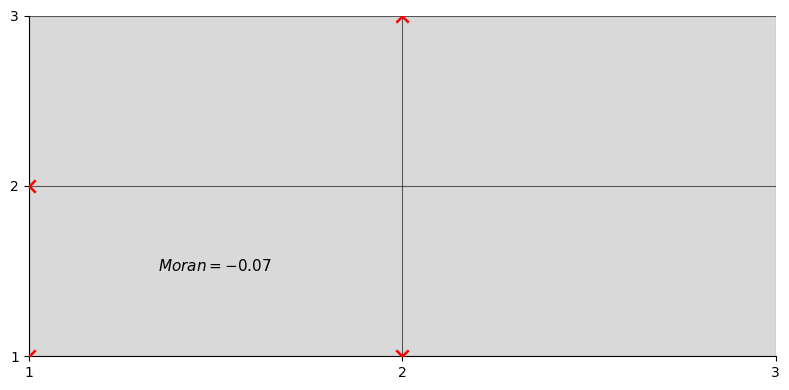

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from graphical_sampling.index import Moran
coords_data = np.array([
    (1,1),(1,2),(1,3),
    (2,1),(2,2),(2,3),
    (3,1),(3,2),(3,3)
])
coords = coords_data
sample = design.sample(1)[0]

# Moran
moran_index = Moran(pop)
moran_val = moran_index.score(np.array([sample]))[0]

# =========================================================
# 🔴 Figure (match your style)
# =========================================================
fig, ax = plt.subplots(figsize=(8, 4))

# --- background ---
ax.set_facecolor("#d9d9d9")   # light gray panel
# --- grid lines (only internal structure) ---
x_vals = np.unique(coords[:,0])
y_vals = np.unique(coords[:,1])

for x in x_vals:
    ax.axvline(x, color='black', lw=0.8, alpha=0.6, zorder=0)

for y in y_vals:
    ax.axhline(y, color='black', lw=0.8, alpha=0.6, zorder=0)

# --- sample (crosses only, no population dots) ---
ax.scatter(coords[sample, 0], coords[sample, 1],
           color="red", marker='x', s=80, linewidths=1.8, zorder=5)

# --- ticks exactly like figure ---
ax.set_xticks(x_vals)
ax.set_yticks(y_vals)

# --- limits tight ---
ax.set_xlim(x_vals.min(), x_vals.max())
ax.set_ylim(y_vals.min(), y_vals.max())

# --- clean axes ---
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Moran annotation (subtle, like your figure) ---
ax.text(1.5, y_vals.min()+0.5,
        rf"$Moran={moran_val:.2f}$",
        ha='center', fontsize=11)

plt.tight_layout()
plt.show()

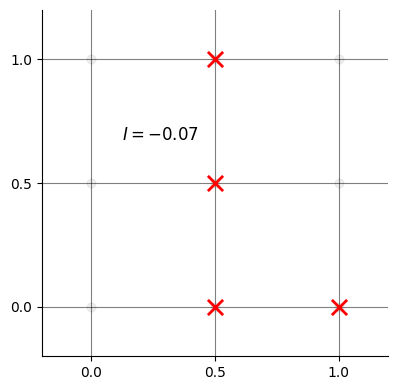

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from graphical_sampling.index import Moran

# --- coords & sample already defined ---
coords = pop.coords

# --- sample ---
sample = design.sample(1)[0]

# --- Moran ---
moran_index = Moran(pop)
moran_val = moran_index.score(np.array([sample]))[0]

# =========================================================
# 🔴 Manual plotting
# =========================================================
fig, ax = plt.subplots(figsize=(6, 4))

# --- population points (light) ---
ax.scatter(coords[:, 0], coords[:, 1],
           color="black", s=40, alpha=0.06, zorder=1)

# --- sample (crosses) ---
ax.scatter(coords[sample, 0], coords[sample, 1],
           color="red", marker='x', s=120, linewidths=2, zorder=3)

# --- optional: grid lines (like your figure) ---
for x in np.unique(coords[:,0]):
    ax.axvline(x, color='black', lw=0.8, alpha=0.5, zorder=0)

for y in np.unique(coords[:,1]):
    ax.axhline(y, color='black', lw=0.8, alpha=0.5, zorder=0)

# --- limits & ticks ---
ax.set_xlim(coords[:,0].min()-0.2, coords[:,0].max()+0.2)
ax.set_ylim(coords[:,1].min()-0.2, coords[:,1].max()+0.2)

ax.set_xticks(np.unique(coords[:,0]))
ax.set_yticks(np.unique(coords[:,1]))

# --- Moran text ---
x_mean, y_mean = coords[sample].mean(axis=0)
ax.text(x_mean-0.5, y_mean+0.3,
        rf"$I={moran_val:.2f}$",
        fontsize=12)

# --- style (paper-like) ---
ax.set_aspect('equal')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### For sampling

In [57]:
# =========================================================
# CELL 2
# ROBERTSON VARIABLES
# =========================================================

def robertson_variables(x1, x2, positive_shift=True):
    """Robertson artificial response functions.

    Note:
    peak and bird are shifted by +7 and +6, respectively.
    """

    corrugated = (
        3 * (x1 + x2)
        +
        np.sin(6 * (x1 + x2))
    )

    peak = (
        3 * (4 - 6*x1)**2
        *
        np.exp(
            -(6*x1 - 3)**2
            -
            (6*x2 - 2)**2
        )
        -
        10
        *
        (
            0.2*(6*x1 - 3)
            -
            (6*x1 - 3)**3
            -
            (6*x2 - 3)**5
        )
        *
        np.exp(
            -(6*x1 - 3)**2
            -
            (6*x2 - 3)**2
        )
        -
        (1/3)
        *
        np.exp(
            -(6*x1 - 2)**2
            -
            (6*x2 - 3)**2
        )
    )

    bird = (
        1/20
        *
        (
            (12*x1 - 12*x2)**2
            +
            np.exp(
                (1 - np.sin(12*x1 - 6))**2
            )
            *
            np.cos(12*x2 - 6)
            +
            np.exp(
                (1 - np.cos(12*x2 - 6))**2
            )
            *
            np.sin(12*x1 - 6)
        )
    )

    if positive_shift:
        peak = peak + 7
        bird = bird + 6

    return {
        "corrugated": corrugated,
        "plane": corrugated,
        "peak": peak,
        "bird": bird,
    }

print("Robertson variables defined.")

Robertson variables defined.


In [58]:
import os
os.getcwd()
# os.chdir("/home/bardia/graphical-sampling")
# os.chdir("/home/bardia/graphical-sampling/simulations")
# os.chdir('/config/ws/graphical-sampling/simulations')
# os.chdir('/Users/Apc/graphical-sampling/simulations')
os.chdir('/home/bardia/projects/graphical-sampling/simulations')
from package_sampling.utils import inclusion_probabilities

import os
import pandas as pd
import numpy as np

# Assuming inclusion_probabilities is defined elsewhere or imported
# from your package
files = ["aggregated.csv", "regular.csv", "meuse.csv", "swiss.csv", "aggregated_1000.csv", "regular_1000.csv",
         "AggregatedPop1000.csv", "RegularPop1000.csv"]

def popus(n, path="populations/real"):
    dfs = {} # Better to define inside to keep it clean
    for f in files:
        full_path = os.path.join(path, f)
        if not os.path.exists(full_path):
            print(f"Warning: {full_path} not found.")
            continue
            
        df = pd.read_csv(full_path)
        N_pop = len(df)
        name = f.replace('.csv', '')
        
        # Equal Probabilities (Standard for all)
        pik_ep = np.repeat(n / N_pop, N_pop)
        
        if f in ["aggregated.csv", "regular.csv",  "aggregated_1000.csv", "regular_1000.csv",
                  "AggregatedPop1000.csv", "RegularPop1000.csv"]:
            coords = df.to_numpy()
            dfs[f'df_{name}'] = pd.DataFrame({
                'coord_x': coords[:, 0],
                'coord_y': coords[:, 1],
                'pik_ep' : pik_ep,
                'z'      : np.ones(N_pop) # Placeholder if z is missing
            })

        elif f == "meuse.csv":
            coords = df[['x', 'y']].to_numpy()
            # Unequal Probabilities (UP)
            pik_up = inclusion_probabilities(df['copper'].to_numpy().copy(), n)
            dfs[f'df_{name}'] = pd.DataFrame({
                'coord_x': coords[:, 0],
                'coord_y': coords[:, 1],
                'pik_ep' : pik_ep,
                'pik_up' : pik_up,
                'z'      : df['cadmium']
            })

        elif f == "swiss.csv":
            coords = df[['x', 'y']].to_numpy()
            AREA = df['AREA'].to_numpy().clip(5, 100)
            pik_up = inclusion_probabilities(AREA.copy(), n)
            dfs[f'df_{name}'] = pd.DataFrame({
                'coord_x': coords[:, 0],
                'coord_y': coords[:, 1],
                'pik_ep' : pik_ep,
                'pik_up' : pik_up,
                'z'      : df['AREA_A']
            })
            
    return dfs

Computing : EP | Pure Random Order GFS Baseline
Computing : EP | Points: Random, Zones: Random
Computing : EP | Points: Snake Move, Zones: Lexicoyx
Computing : UP | Pure Random Order GFS Baseline
Computing : UP | Points: Random, Zones: Random
Computing : UP | Points: Snake Move, Zones: Lexicoyx


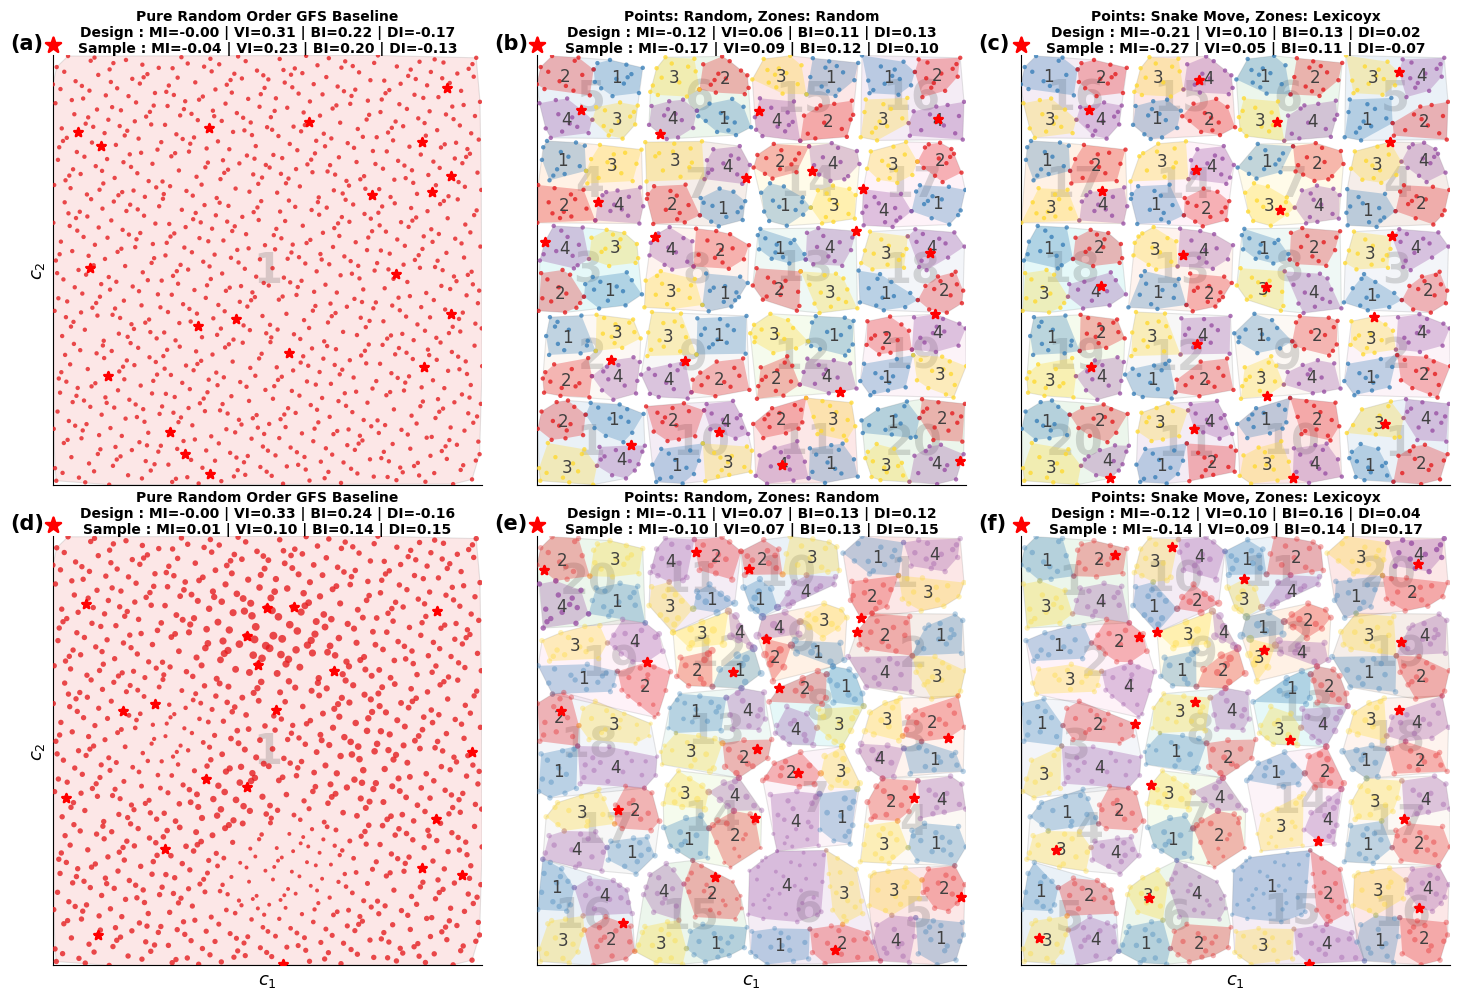

Saved : panel_a.pdf
Saved : panel_b.pdf
Saved : panel_c.pdf
Saved : panel_d.pdf
Saved : panel_e.pdf
Saved : panel_f.pdf


In [67]:
import matplotlib.pyplot as plt
import numpy as np
import graphical_sampling as gs

from graphical_sampling.index import (
    Moran,
    Voronoi,
    LocalBalance,
    DensityDisparity
)

from package_sampling.utils import inclusion_probabilities

# =========================================================
# PARAMETERS
# =========================================================
popu = 'df_RegularPop1000'
ep_or_up = 'pik_ep'
n = 20

df = popus(n)[popu]

coords_data = df[['coord_x', 'coord_y']].to_numpy()

variable_data = df['z'].to_numpy()

N = len(coords_data)

# =========================================================
# EQUAL PROBABILITIES
# =========================================================
inclusions_equal = df[ep_or_up].to_numpy()

pop_equal = gs.Population(
    coords_data,
    inclusions_equal,
    n=n,
    variable=variable_data
)

# =========================================================
# UNEQUAL PROBABILITIES
# =========================================================
inclusions_unequal = inclusion_probabilities(
    np.clip(np.random.random(N), .2, .8),
    n
)
x1 = coords_data[:, 0]
x2 = coords_data[:, 1]
vars_rob = robertson_variables(x1, x2)

inclusions_unequal = inclusion_probabilities(vars_rob["peak"], n)

pop_unequal = gs.Population(
    coords_data,
    inclusions_unequal,
    n=n,
    variable=variable_data
)

# =========================================================
# CONFIGURATIONS
# =========================================================
configs = [

    dict(
        point_strategy='random',
        zone_strategy='random',
        zone_mode='sweep_yx',
        num_zones=(1,1),
        centroid_grid_x=1,
        r_sample_per_cluster=20,
        title='Pure Random Order GFS Baseline'
    ),

    dict(
        point_strategy='random',
        zone_strategy='random',
        zone_mode='sweep_yx',
        num_zones=(2,2),
        centroid_grid_x=4,
        r_sample_per_cluster=1,
    ),

    dict(
        point_strategy='snake_move',
        zone_strategy='lexicoYX',
        zone_mode='sweep_yx',
        num_zones=(2,2),
        centroid_grid_x=4,
        r_sample_per_cluster=1,
    )
]

# =========================================================
# AUTOMATIC TITLES
# =========================================================
for cfg in configs:

    if cfg['r_sample_per_cluster'] == 20:

        cfg['title'] = 'Pure Random Order GFS Baseline'

    else:

        cfg['title'] = (
            f"Points: {cfg['point_strategy'].replace('_', ' ').title()}, "
            f"Zones: {cfg['zone_strategy'].replace('_', ' ').title()}"
        )

# =========================================================
# POPULATIONS
# =========================================================
all_pops = [

    (
        "EP",
        pop_equal,
        inclusions_equal,
        1
    ),

    (
        "UP",
        pop_unequal,
        inclusions_unequal,
        0.001
    )
]

# =========================================================
# PANEL LABELS
# =========================================================
panel_labels = ['a', 'b', 'c', 'd', 'e', 'f']

# =========================================================
# STORAGE
# =========================================================
stored_results = []

panel_counter = 0

# =========================================================
# COMPUTE EVERYTHING ONCE
# =========================================================
for row_idx, (
    row_title,
    current_pop,
    current_inclusions,
    current_split_size
) in enumerate(all_pops):

    # -----------------------------------------------------
    # INDEXERS
    # -----------------------------------------------------
    moran_indexer = Moran(current_pop, method='tille')

    voronoi_indexer = Voronoi(current_pop)

    balance_indexer = LocalBalance(current_pop)

    disparity_indexer = DensityDisparity(current_pop)

    # -----------------------------------------------------
    # LOOP OVER CONFIGS
    # -----------------------------------------------------
    for col_idx, cfg in enumerate(configs):

        print(f"Computing : {row_title} | {cfg['title']}")

        # -------------------------------------------------
        # CLUSTERING
        # -------------------------------------------------
        fbn = gs.clustering.FIPBalancedNMeans(
            n=n,
            centroid_grid_x=cfg['centroid_grid_x'],
            r_sample_per_cluster=cfg['r_sample_per_cluster'],
            init_clust_method='expanded',
            split_size=current_split_size
        )

        fbn.fit(current_pop)

        fbn.fit_zones(
            num_zones=cfg['num_zones'],
            mode=cfg['zone_mode']
        )

        # -------------------------------------------------
        # ORDER
        # -------------------------------------------------
        order = gs.Order.from_clusters(
            current_pop,
            fbn.clusters,
            zone_strategy=cfg['zone_strategy'],
            point_strategy=cfg['point_strategy'],
            num_splits=1,
            topological=True,
            shift_jump=2,
            shuffle=False,
            grid_dims=cfg['num_zones']
        )

        fbn.clusters = order.clusters

        # -------------------------------------------------
        # DESIGN
        # -------------------------------------------------
        design = gs.Design.from_order(
            current_pop,
            order
        )

        coords = design.pop.coords

        # -------------------------------------------------
        # SAMPLE
        # -------------------------------------------------
        sample_indices_2d = design.sample(1)

        sample_indices = sample_indices_2d[0]

        # -------------------------------------------------
        # SAMPLE METRICS
        # -------------------------------------------------
        mi_s = moran_indexer.score(sample_indices_2d)[0]

        vi_s = voronoi_indexer.score(sample_indices_2d)[0]

        bi_s = balance_indexer.score(sample_indices_2d)[0]

        di_s = disparity_indexer.score(sample_indices_2d)[0]

        # -------------------------------------------------
        # DESIGN METRICS
        # -------------------------------------------------
        mi_e = design.moran[0]

        vi_e = design.voronoi[0]

        bi_e = design.local_balance[0]

        di_e = design.density_disparity[0]

        # -------------------------------------------------
        # STORE
        # -------------------------------------------------
        stored_results.append({

            'row_title': row_title,

            'cfg': cfg,

            'fbn': fbn,

            'coords': coords,

            'sample_indices': sample_indices,

            'sample_metrics': (
                mi_s,
                vi_s,
                bi_s,
                di_s
            ),

            'design_metrics': (
                mi_e,
                vi_e,
                bi_e,
                di_e
            ),

            'panel_label': panel_labels[panel_counter]
        })

        panel_counter += 1

# =========================================================
# PLOTTING FUNCTION
# =========================================================
def draw_panel(ax, res, show_x=True, show_y=True, show_panel_label=True):

    fbn = res['fbn']

    coords = res['coords']

    sample_indices = res['sample_indices']

    cfg = res['cfg']

    row_title = res['row_title']

    mi_s, vi_s, bi_s, di_s = res['sample_metrics']

    mi_e, vi_e, bi_e, di_e = res['design_metrics']

    # -----------------------------------------------------
    # SIZE SCALE
    # -----------------------------------------------------
    if row_title == "EP":

        size_scale = 500

    else:

        size_scale = 800

    # -----------------------------------------------------
    # BACKGROUND
    # -----------------------------------------------------
    fbn.plot(
        mode='soft',
        ax=ax,
        show_zone_sub_hulls=True,
        show_zone_labels=True,
        zone_color_mode=True,
        size_scale=size_scale
    )

    # -----------------------------------------------------
    # FADE UNEQUAL
    # -----------------------------------------------------
    if row_title == "UP":

        for coll in ax.collections[:-1]:

            try:
                coll.set_alpha(0.35)

            except:
                pass

    # -----------------------------------------------------
    # CLUSTER LABELS
    # -----------------------------------------------------
    for i, cluster in enumerate(fbn.clusters):

        cluster_points = []

        for zone in cluster.zones:

            cluster_points.extend(zone.indices)

        cluster_points = np.array(cluster_points)

        centroid = coords[cluster_points].mean(axis=0)

        ax.text(
            centroid[0],
            centroid[1],
            f"{i+1}",
            fontsize=30,
            color='black',
            alpha=0.14,
            ha='center',
            va='center',
            weight='bold',
            zorder=1
        )

    # -----------------------------------------------------
    # SAMPLE POINTS
    # -----------------------------------------------------
    ax.scatter(
        coords[sample_indices, 0],
        coords[sample_indices, 1],
        marker='*',
        color='red',
        s=42,
        linewidths=1.8,
        zorder=20
    )

    # -----------------------------------------------------
    # TITLE
    # -----------------------------------------------------
    title = (
        # f"{row_title} - {cfg['title']}\n"
        f"{cfg['title']}\n"
        f"Design : "
        f"MI={mi_e:.2f} | "
        f"VI={vi_e:.2f} | "
        f"BI={bi_e:.2f} | "
        f"DI={di_e:.2f}\n"
        f"Sample : "
        f"MI={mi_s:.2f} | "
        f"VI={vi_s:.2f} | "
        f"BI={bi_s:.2f} | "
        f"DI={di_s:.2f}"
    )

    ax.set_title(
        title,
        fontsize=10,
        fontweight='bold',
        family='DejaVu Sans',
        pad=2
    )

    # -----------------------------------------------------
    # PANEL LABEL
    # -----------------------------------------------------
    # -----------------------------------------------------
# PANEL LABEL
# -----------------------------------------------------
    if show_panel_label:

        ax.text(
                        -0.10,
                        1.03,
                        f"({res['panel_label']})",
                        transform=ax.transAxes,
                        fontsize=15,
                        fontweight='bold',
                        va='center'
        )

    # -----------------------------------------------------
    # SAMPLE SYMBOL
    # -----------------------------------------------------
    ax.scatter(
    [0.00],
    [1.025],
    transform=ax.transAxes,
    marker='*',
    color='red',
    s=130,
    linewidths=1.8,
    clip_on=False,
    zorder=100
)

    # -----------------------------------------------------
    # AXES
    # -----------------------------------------------------
    if show_x:

        ax.set_xlabel(r"$c_1$", fontsize=13)

    else:

        ax.set_xticks([])
        ax.set_xlabel("")

    if show_y:

        ax.set_ylabel(r"$c_2$", fontsize=13)

    else:

        ax.set_ylabel("")
        ax.set_yticks([])

    ax.set_aspect('equal')

    ax.margins(0)

    ax.set_xlim(coords[:,0].min(), coords[:,0].max())

    ax.set_ylim(coords[:,1].min(), coords[:,1].max())

# =========================================================
# CREATE ALL-IN-ONE FIGURE
# =========================================================
fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 10),
    constrained_layout=False,
    gridspec_kw={
        'wspace': -0.05,
        'hspace': 0.12
    }
)

for k, res in enumerate(stored_results):

    row = k // 3

    col = k % 3

    ax = axes[row, col]

    draw_panel(
        ax,
        res,
        show_x=(row == 1),
        show_y=(col == 0)
    )

plt.subplots_adjust(
    left=0.01,
    right=0.995,
    top=0.96,
    bottom=0.05,
    wspace=-0.20,
    hspace=0.16
)

plt.show()

# =========================================================
# SAVE INDEPENDENT PANELS
# =========================================================
for k, res in enumerate(stored_results):

    fig, ax = plt.subplots(
        figsize=(6.2, 5.2)
    )

    draw_panel(
        ax,
        res,
        show_x=True,
        show_y=True,
        show_panel_label=False
    )

    plt.tight_layout()

    filename = f"panel_{res['panel_label']}.pdf"

    plt.savefig(
        filename,
        dpi=400,
        bbox_inches='tight'
    )

    plt.close()

    print(f"Saved : {filename}")

### plot a simple example of orders

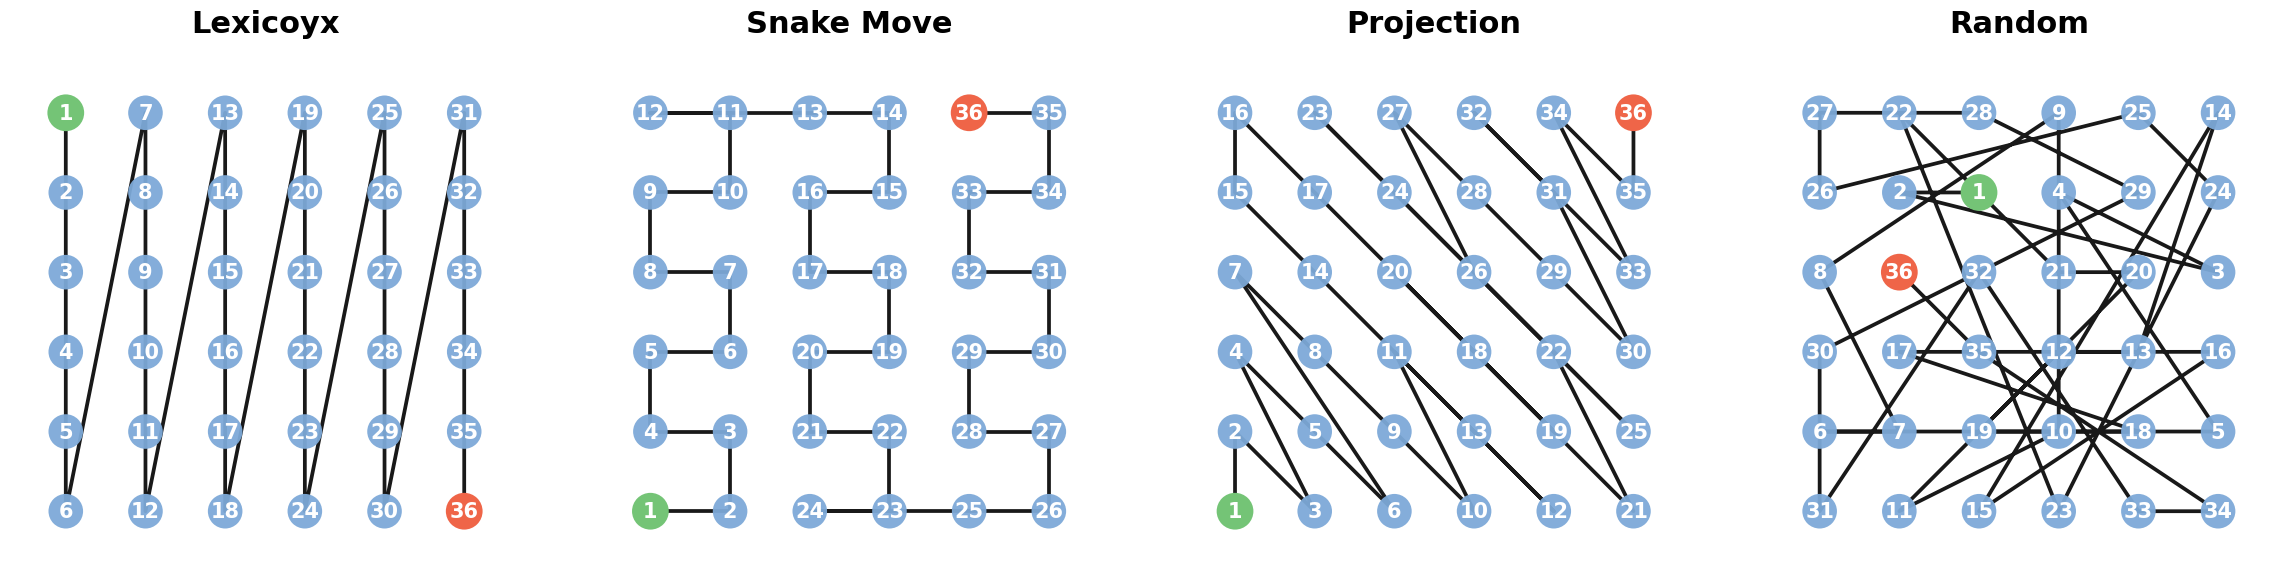

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import graphical_sampling as gs

# =========================================================
# CREATE PERFECT GRID POPULATION
# =========================================================
M = 6

x = np.repeat(np.arange(M), M)
y = np.tile(np.arange(M)[::-1], M)

coords = np.column_stack([
    x,
    y
]).astype(float)

N = len(coords)
n = 16

# =========================================================
# EQUAL INCLUSION PROBABILITIES
# =========================================================
pik = np.repeat(n / N, N)

z = np.arange(N)

df = pd.DataFrame({
    'coord_x': coords[:, 0],
    'coord_y': coords[:, 1],
    'pik_ep': pik,
    'z': z
})

# =========================================================
# POPULATION
# =========================================================
pop = gs.Population(
    coords,
    pik,
    n=n,
    variable=z
)

# =========================================================
# STRATEGIES
# =========================================================
strategies = [
    'lexicoYX',
    'snake_move',
    'projection',
    'random'
]

titles = [
    "Lexicoyx",
    "Snake Move",
    "Projection",
    "Random"
]

# =========================================================
# FIGURE
# =========================================================
fig, axes = plt.subplots(
    1,
    4,
    figsize=(24, 6),
    gridspec_kw={'wspace': 0.04}
)

# =========================================================
# MAIN LOOP
# =========================================================
for ax, strategy, title in zip(axes, strategies, titles):

    # -----------------------------------------------------
    # ORDER
    # -----------------------------------------------------
    order_idx = gs.Order(pop)._get_strategy_order(
        coords,
        strategy=strategy,
        topological=True,
        grid_dims=(M, M)
    )

    ordered_coords = coords[order_idx]

    # -----------------------------------------------------
    # CONNECTION PATH
    # -----------------------------------------------------
    ax.plot(
        ordered_coords[:, 0],
        ordered_coords[:, 1],
        color='black',
        linewidth=2.7,
        solid_capstyle='round',
        solid_joinstyle='round',
        alpha=0.9,
        zorder=1
    )

    # -----------------------------------------------------
    # MAIN POINTS
    # -----------------------------------------------------
    ax.scatter(
        coords[:, 0],
        coords[:, 1],
        s=620,
        color='#7da9d8',
        edgecolors='none',
        alpha=0.95,
        zorder=5
    )

    # -----------------------------------------------------
    # START POINT
    # -----------------------------------------------------
    ax.scatter(
        ordered_coords[0, 0],
        ordered_coords[0, 1],
        s=700,
        color='#74c476',
        edgecolors='none',
        zorder=15
    )

    # -----------------------------------------------------
    # END POINT
    # -----------------------------------------------------
    ax.scatter(
        ordered_coords[-1, 0],
        ordered_coords[-1, 1],
        s=700,
        color='#ef6548',
        edgecolors='none',
        zorder=15
    )

    # -----------------------------------------------------
    # LABELS
    # -----------------------------------------------------
    for rank, idx in enumerate(order_idx):

        cx, cy = coords[idx]

        ax.text(
            cx,
            cy,
            str(rank + 1),
            fontsize=15,
            fontweight='bold',
            color='white',
            ha='center',
            va='center',
            zorder=20
        )

    # -----------------------------------------------------
    # TITLE
    # -----------------------------------------------------
    ax.set_title(
        title,
        fontsize=22,
        fontweight='bold',
        pad=18
    )

    # -----------------------------------------------------
    # STYLE
    # -----------------------------------------------------
    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_aspect('equal')

    ax.set_xlim(-0.7, M - 0.3)
    ax.set_ylim(-0.7, M - 0.3)

    # remove borders
    for spine in ax.spines.values():
        spine.set_visible(False)

# =========================================================
# FINAL LAYOUT
# =========================================================
plt.subplots_adjust(
    left=0.02,
    right=0.985,
    top=0.90,
    bottom=0.05,
    wspace=0.05
)

plt.show()

### Meuse and Swiss

#### packages and functions

In [ ]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import os
os.getcwd()
# os.chdir("/home/bardia/graphical-sampling")
# os.chdir("/home/bardia/graphical-sampling/simulations")
# os.chdir('/config/ws/graphical-sampling/simulations')
# os.chdir('/Users/Apc/graphical-sampling/simulations')
# os.chdir('/home/dell/projects/graphical-sampling/simulations')
os.chdir('/home/bardia/projects/graphical-sampling/simulations')


In [ ]:
from itertools import product
import numpy as np
import graphical_sampling as gs
from tqdm import tqdm
from package_sampling.utils import inclusion_probabilities
import numpy as np
import pandas as pd



In [ ]:
def robertson_variables(x1, x2, positive_shift=True):

    corrugated = (
        3 * (x1 + x2)
        +
        np.sin(6 * (x1 + x2))
    )

    peak = (
        (
            3 * (4 - 6*x1)**2
            *
            np.exp(
                -(6*x1 - 3)**2
                -
                (6*x2 - 2)**2
            )
            -
            10
            *
            (
                0.2*(6*x1 - 3)
                -
                (6*x1 - 3)**3
                -
                (6*x2 - 3)**5
            )
            *
            np.exp(
                -(6*x1 - 3)**2
                -
                (6*x2 - 3)**2
            )
            -
            (1/3)
            *
            np.exp(
                -(6*x1 - 2)**2
                -
                (6*x2 - 3)**2
            )
        )
    )

    bird = (
        1/20
        *
        (
            (12*x1 - 12*x2)**2
            +
            np.exp(
                (1 - np.sin(12*x1 - 6))**2
            )
            *
            np.cos(12*x2 - 6)
            +
            np.exp(
                (1 - np.cos(12*x2 - 6))**2
            )
            *
            np.sin(12*x1 - 6)
        )
    )

    if positive_shift:

        peak = peak + 7

        bird = bird + 6

    return {

        "corrugated": corrugated,

        "plane": corrugated,

        "peak": peak,

        "bird": bird,
    }

In [ ]:
# =========================================================
# LOAD POPULATIONS
# =========================================================

import os
import pandas as pd
import numpy as np

from package_sampling.utils import inclusion_probabilities

# =========================================================
# FILES
# =========================================================

files = [

    "meuse.csv",

    "swiss.csv",

    "AggregatedPop1000.csv",

    "RegularPop1000.csv"
]

# =========================================================
# POPULATION LOADER
# =========================================================

def popus(n, path="populations/real"):

    dfs = {}

    for f in files:

        full_path = os.path.join(path, f)

        # -------------------------------------------------
        # Check existence
        # -------------------------------------------------

        if not os.path.exists(full_path):

            print(f"Warning: {full_path} not found.")

            continue

        # -------------------------------------------------
        # Read file
        # -------------------------------------------------

        df = pd.read_csv(full_path)

        N_pop = len(df)

        name = f.replace(".csv", "")

        # -------------------------------------------------
        # Equal probabilities
        # -------------------------------------------------

        pik_ep = np.repeat(
            n / N_pop,
            N_pop
        )


        # =================================================
        # ROBERTSON POPULATIONS
        # =================================================

        # =================================================
# ROBERTSON POPULATIONS
# =================================================

        if f in ["AggregatedPop1000.csv", "RegularPop1000.csv"]:

            coords = df.to_numpy()

            x1 = coords[:, 0]
            x2 = coords[:, 1]

            vars_robertson = robertson_variables(x1, x2)

            plane = vars_robertson["plane"]

            def noisy_through_origin(x, rho, seed=None):

                rng = np.random.default_rng(seed)

                e = rng.normal(size=len(x))
                e = (e - e.mean()) / e.std()

                # noise level corresponding to target correlation
                noise_ratio = np.sqrt(1 / (rho**2) - 1)

                y = x + noise_ratio * x.std() * e

                return y

            dfs[f"df_{name}"] = pd.DataFrame({

                "coord_x" : x1,
                "coord_y" : x2,

                "pik_ep" : pik_ep,

                "z" : vars_robertson["corrugated"],

                "plane" : plane,
                "peak" : vars_robertson["peak"],
                "bird" : vars_robertson["bird"],

                "plane_rho_07" : noisy_through_origin(plane, 0.7, seed=701),
                "plane_rho_08" : noisy_through_origin(plane, 0.8, seed=801),
                "plane_rho_09" : noisy_through_origin(plane, 0.9, seed=901),
            })
            
        
        elif f == "meuse.csv":

            coords = df[["x", "y"]].to_numpy()

            # unequal probabilities
            pik_up = inclusion_probabilities(

                df["copper"].to_numpy().copy(),

                n
            )

            dfs[f"df_{name}"] = pd.DataFrame({

                "coord_x" : coords[:, 0],

                "coord_y" : coords[:, 1],

                "pik_ep" : pik_ep,

                "pik_up" : pik_up,

                "z" : df["cadmium"]
            })

        # =================================================
        # SWISS
        # =================================================

        elif f == "swiss.csv":

            coords = df[["x", "y"]].to_numpy()

            AREA = df["AREA"].to_numpy().clip(
                5,
                100
            )

            pik_up = inclusion_probabilities(

                AREA.copy(),

                n
            )

            dfs[f"df_{name}"] = pd.DataFrame({

                "coord_x" : coords[:, 0],

                "coord_y" : coords[:, 1],

                "pik_ep" : pik_ep,

                "pik_up" : pik_up,

                "z" : df["AREA_A"]
            })

    return dfs

# =========================================================
# LOAD MAIN POPULATIONS
# =========================================================

p50 = popus(50)

regular = p50["df_RegularPop1000"]

aggregated = p50["df_AggregatedPop1000"]

meuse = p50["df_meuse"]

swiss = p50["df_swiss"]

# =========================================================
# CHECK
# =========================================================

print("\n================================================")
print("POPULATIONS LOADED")
print("================================================\n")

print("regular:", regular.shape)

print("aggregated:", aggregated.shape)

print("meuse:", meuse.shape)

print("swiss:", swiss.shape)


POPULATIONS LOADED

regular: (1000, 10)
aggregated: (1000, 10)
meuse: (155, 5)
swiss: (959, 5)


#### Switzerland

In [ ]:
import numpy as np
import graphical_sampling as gs

# ---------------------------------------------------------
# Parameters
# ---------------------------------------------------------
popu = "df_swiss"
ep_or_up = "pik_up"
n = 50

centroid_grid_x = 4
r_sample_per_cluster = 1

# ---------------------------------------------------------
# Population
# ---------------------------------------------------------
df = popus(n)[popu]

coords_data = df[["coord_x", "coord_y"]].to_numpy()
inclusions_data = df[ep_or_up].to_numpy()

pop = gs.Population(
    coords_data,
    inclusions_data,
    n=n
)

# ---------------------------------------------------------
# FIP-balanced n-means clustering
# ---------------------------------------------------------
fbn_swiss = gs.clustering.FIPBalancedNMeans(
    n=n,
    r_sample_per_cluster=r_sample_per_cluster,
    centroid_grid_x=centroid_grid_x,
    init_clust_method="expanded",
    split_size=0.0001
)

fbn_swiss.fit(pop)

# ---------------------------------------------------------
# Zones inside clusters
# ---------------------------------------------------------
fbn_swiss.fit_zones(
    num_zones=(2, 2),
    mode="sweep_xy"
)

In [ ]:
import geopandas as gpd

zip_path = "maps/swiss/ne_10m_admin_0_countries.zip"

world = gpd.read_file(f"zip://{zip_path}")
swiss_gdf = world[world["ADMIN"] == "Switzerland"].copy()

In [ ]:
from shapely import affinity

# ---------------------------------------------------------
# Detect the coordinate system of df and transform boundary
# ---------------------------------------------------------
x_min, y_min = df[["coord_x", "coord_y"]].min()
x_max, y_max = df[["coord_x", "coord_y"]].max()

swiss_raw = swiss_gdf.copy()

if x_max > 1_000_000:
    # Swiss LV95
    swiss_raw = swiss_raw.to_crs("EPSG:2056")
elif x_max > 100_000:
    # Swiss LV03
    swiss_raw = swiss_raw.to_crs("EPSG:21781")
else:
    # longitude/latitude
    swiss_raw = swiss_raw.to_crs("EPSG:4326")

# ---------------------------------------------------------
# Normalize exactly as gs.Population normalizes coordinates
# ---------------------------------------------------------
x0 = df["coord_x"].min()
y0 = df["coord_y"].min()

scale = max(
    df["coord_x"].max() - df["coord_x"].min(),
    df["coord_y"].max() - df["coord_y"].min()
)

swiss_norm = swiss_raw.copy()
swiss_norm["geometry"] = swiss_norm.geometry.translate(xoff=-x0, yoff=-y0)
swiss_norm["geometry"] = swiss_norm.geometry.scale(
    xfact=1/scale,
    yfact=1/scale,
    origin=(0, 0)
)

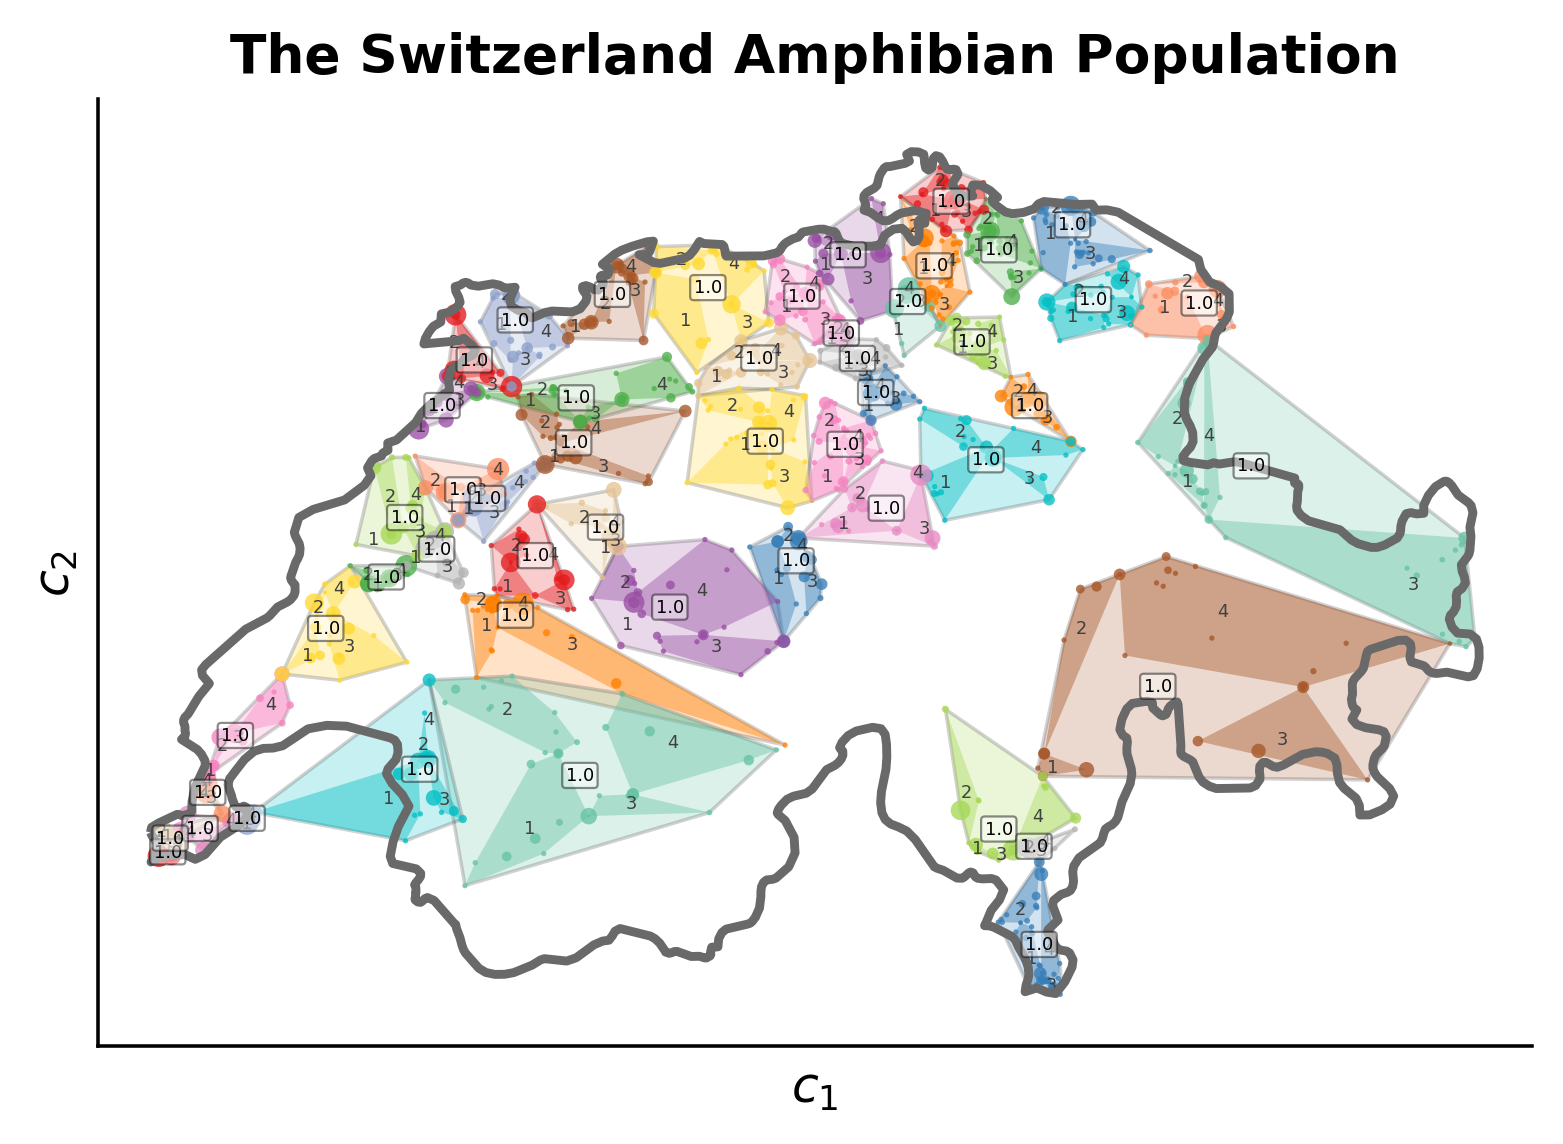

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4), dpi=320)

# Switzerland boundary
swiss_norm.boundary.plot(
    ax=ax,
    color="dimgray",
    linewidth=2,
    zorder=20
)

# FIP-balanced clusters
fbn_swiss.plot(
    mode="soft",
    ax=ax,
    background_gdf=None,
    show_zone_sub_hulls=True,
    show_zone_labels=True,
    show_centroids=False,
    connect_centroids=False,
    show_cluster_mass=True,
    size_scale=100,
    point_size_min=0,
    point_size_max=10_000
)

# Limits from Switzerland boundary
xmin, ymin, xmax, ymax = swiss_norm.total_bounds
pad = 0.04

ax.set_xlim(xmin - pad, xmax + pad)
ax.set_ylim(ymin - pad, ymax + pad)

ax.set_title("The Switzerland Amphibian Population", fontsize=12, weight="bold")

ax.set_xlabel(r"$c_1$", fontsize=11)
ax.set_ylabel(r"$c_2$", fontsize=11)

ax.set_aspect("equal")

fig.subplots_adjust(
    left=0.10,
    right=0.98,
    bottom=0.14,
    top=0.88
)

fig.savefig("plots/swiss_fip_clusters_single.pdf", bbox_inches="tight", pad_inches=0.02)
fig.savefig("plots/swiss_fip_clusters_single.png", dpi=320, bbox_inches="tight", pad_inches=0.02)
plt.show()

NameError: name 'swiss_norm' is not defined

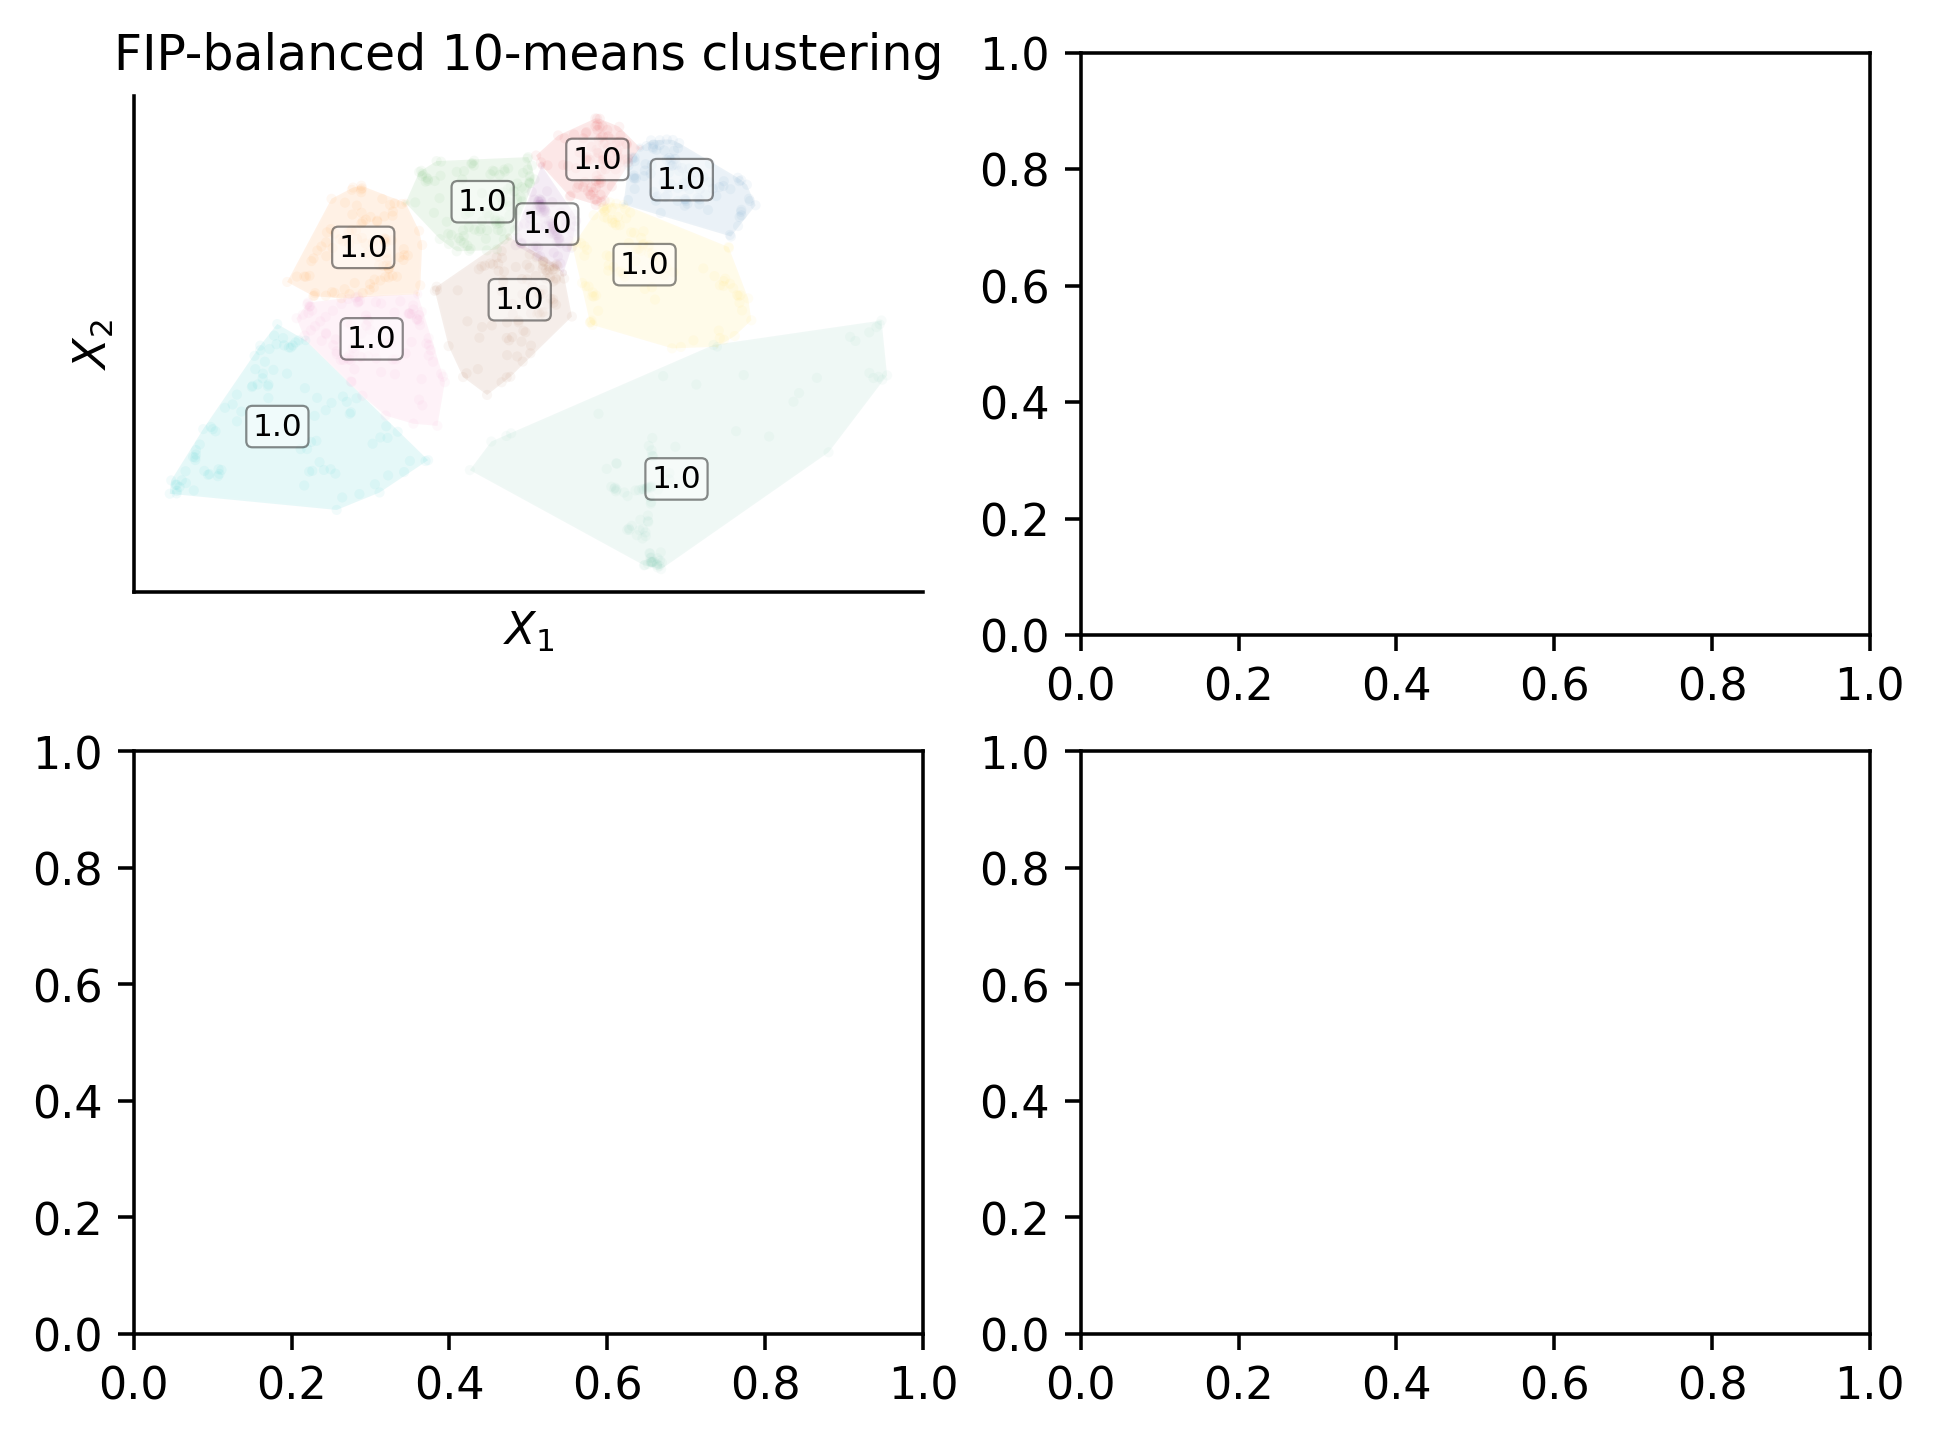

In [ ]:
import matplotlib.pyplot as plt
import graphical_sampling as gs

# =========================================================
# PARAMETERS
# =========================================================
popu = "df_swiss"
n = 10

centroid_grid_x = 4
r_sample_per_cluster = 1

df_ep = popus(n)[popu]
df_up = popus(n)[popu]

# =========================================================
# POPULATIONS
# =========================================================
coords_ep = df_ep[["coord_x", "coord_y"]].to_numpy()
pik_ep = df_ep["pik_ep"].to_numpy()

coords_up = df_up[["coord_x", "coord_y"]].to_numpy()
pik_up = df_up["pik_up"].to_numpy()

pop_ep = gs.Population(coords_ep, pik_ep, n=n)
pop_up = gs.Population(coords_up, pik_up, n=n)

# =========================================================
# EP-BALANCED N-MEANS
# =========================================================
fbn_ep = gs.clustering.FIPBalancedNMeans(
    n=n,
    r_sample_per_cluster=r_sample_per_cluster,
    centroid_grid_x=centroid_grid_x,
    init_clust_method="expanded",
    split_size=0.0001
)

fbn_ep.fit(pop_ep)

fbn_ep.fit_zones(
    num_zones=(1, 1),
    mode="sweep_xy"
)

# =========================================================
# UP-BALANCED N-MEANS
# =========================================================
fbn_up = gs.clustering.FIPBalancedNMeans(
    n=n,
    r_sample_per_cluster=r_sample_per_cluster,
    centroid_grid_x=centroid_grid_x,
    init_clust_method="expanded",
    split_size=0.0001
)

fbn_up.fit(pop_up)

fbn_up.fit_zones(
    num_zones=(1, 1),
    mode="sweep_xy"
)

# =========================================================
# HELPER: ADD SWITZERLAND BORDER
# =========================================================
def add_swiss_border(ax, linewidth=1.6, color="dimgray"):
    swiss_norm.boundary.plot(
        ax=ax,
        color=color,
        linewidth=linewidth,
        zorder=50
    )

    xmin, ymin, xmax, ymax = swiss_norm.total_bounds
    pad = 0.04
    ax.set_xlim(xmin - pad, xmax + pad)
    ax.set_ylim(ymin - pad, ymax + pad)

# =========================================================
# FIGURE
# =========================================================
fig, axes = plt.subplots(
    2, 2,
    figsize=(7, 5.2),
    dpi=320,
    constrained_layout=False
)

ax11, ax12 = axes[0, 0], axes[0, 1]
ax21, ax22 = axes[1, 0], axes[1, 1]

# ---------------------------------------------------------
# Top-left: EP-balanced clusters
# ---------------------------------------------------------
fbn_ep.plot(
    mode="soft",
    ax=ax11,
    background_gdf=None,
    zone_color_mode=False,
    show_zone_sub_hulls=True,
    show_zone_labels=False,
    show_cluster_mass=True,
    size_scale=500,
    point_alpha=0.75,
    hull_alpha=0.20,
    zone_hull_alpha=0.38,
    point_size_min=0,
    point_size_max=10_000,
    show_centroids=False,
    connect_centroids=False
)

add_swiss_border(ax11)
ax11.set_title("EP-balanced n-Means", fontsize=12, weight="bold")

# ---------------------------------------------------------
# Top-right: UP-balanced clusters
# ---------------------------------------------------------
fbn_up.plot(
    mode="soft",
    ax=ax12,
    background_gdf=None,
    zone_color_mode=False,
    show_zone_sub_hulls=True,
    show_zone_labels=False,
    show_cluster_mass=True,
    size_scale=500,
    point_alpha=0.075,
    hull_alpha=0.20,
    zone_hull_alpha=0.38,
    point_size_min=0,
    point_size_max=10_000,
    show_centroids=False,
    connect_centroids=False
)

add_swiss_border(ax12)
ax12.set_title("UP-balanced n-Means", fontsize=12, weight="bold")

# ---------------------------------------------------------
# Bottom-left: EP scatter plot
# ---------------------------------------------------------
ax21.scatter(
    pop_ep.coords[:, 0],
    pop_ep.coords[:, 1],
    s=500 * pop_ep.inclusions,
    color="gray",
    alpha=0.55,
    edgecolors="none",
    zorder=10
)

add_swiss_border(ax21)

# ---------------------------------------------------------
# Bottom-right: UP scatter plot
# ---------------------------------------------------------
ax22.scatter(
    pop_up.coords[:, 0],
    pop_up.coords[:, 1],
    s=500 * pop_up.inclusions,
    color="gray",
    alpha=0.55,
    edgecolors="none",
    zorder=10
)

add_swiss_border(ax22)

# =========================================================
# CLEAN COMMON STYLE
# =========================================================
for ax in axes.ravel():
    ax.set_aspect("equal")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Keep only left-column row labels
ax11.set_ylabel("Clusters", fontsize=11)
ax21.set_ylabel("Scatter Plot", fontsize=11)

# No y-labels for second column
ax12.set_ylabel("")
ax22.set_ylabel("")

# =========================================================
# FINAL SPACING
# =========================================================
fig.subplots_adjust(
    left=0.04,
    right=0.99,
    bottom=0.04,
    top=0.93,
    wspace=0.02,
    hspace=0.18
)


fig.savefig("plots/swiss_fip_clusters.pdf", bbox_inches="tight")
fig.savefig("plots/swiss_fip_clusters.png", dpi=320, bbox_inches="tight")

plt.show()

#### Meuse

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import pyreadr
import graphical_sampling as gs

from shapely.geometry import Polygon
from shapely import affinity

In [ ]:
# =========================================================
# LOAD MEUSE RIVER
# =========================================================

riv_path = "maps/meuse/meuse.riv.rda"

riv_obj = pyreadr.read_r(riv_path)
meuse_riv = list(riv_obj.values())[0]

river_xy = meuse_riv.iloc[:, :2].to_numpy()

meuse_river_gdf = gpd.GeoDataFrame(
    geometry=[Polygon(river_xy)],
    crs="EPSG:28992"
)


In [ ]:
# =========================================================
# ROTATE POPULATION DATAFRAME
# =========================================================

def rotate_population(df, alpha_degrees, origin="center"):
    df = df.copy()

    x = df["coord_x"].to_numpy()
    y = df["coord_y"].to_numpy()

    if origin == "center":
        x0 = (x.min() + x.max()) / 2
        y0 = (y.min() + y.max()) / 2
    else:
        x0, y0 = origin

    alpha = np.radians(alpha_degrees)
    cos_a = np.cos(alpha)
    sin_a = np.sin(alpha)

    x_c = x - x0
    y_c = y - y0

    df["coord_x"] = x0 + x_c * cos_a - y_c * sin_a
    df["coord_y"] = y0 + x_c * sin_a + y_c * cos_a

    return df


# =========================================================
# ROTATE GEODATAFRAME USING THE SAME ORIGIN AS THE POPULATION
# =========================================================

def rotate_gdf(gdf, alpha_degrees, df_origin):
    x = df_origin["coord_x"].to_numpy()
    y = df_origin["coord_y"].to_numpy()

    origin = (
        (x.min() + x.max()) / 2,
        (y.min() + y.max()) / 2
    )

    gdf_rot = gdf.copy()
    gdf_rot["geometry"] = gdf_rot.geometry.apply(
        lambda geom: affinity.rotate(
            geom,
            alpha_degrees,
            origin=origin,
            use_radians=False
        )
    )

    return gdf_rot


# =========================================================
# NORMALIZE GEODATAFRAME LIKE gs.Population
# =========================================================

def normalize_gdf_like_population(gdf, df):
    x0 = df["coord_x"].min()
    y0 = df["coord_y"].min()

    scale = max(
        df["coord_x"].max() - df["coord_x"].min(),
        df["coord_y"].max() - df["coord_y"].min()
    )

    gdf_norm = gdf.copy()
    gdf_norm["geometry"] = gdf_norm.geometry.translate(xoff=-x0, yoff=-y0)
    gdf_norm["geometry"] = gdf_norm.geometry.scale(
        xfact=1 / scale,
        yfact=1 / scale,
        origin=(0, 0)
    )

    return gdf_norm

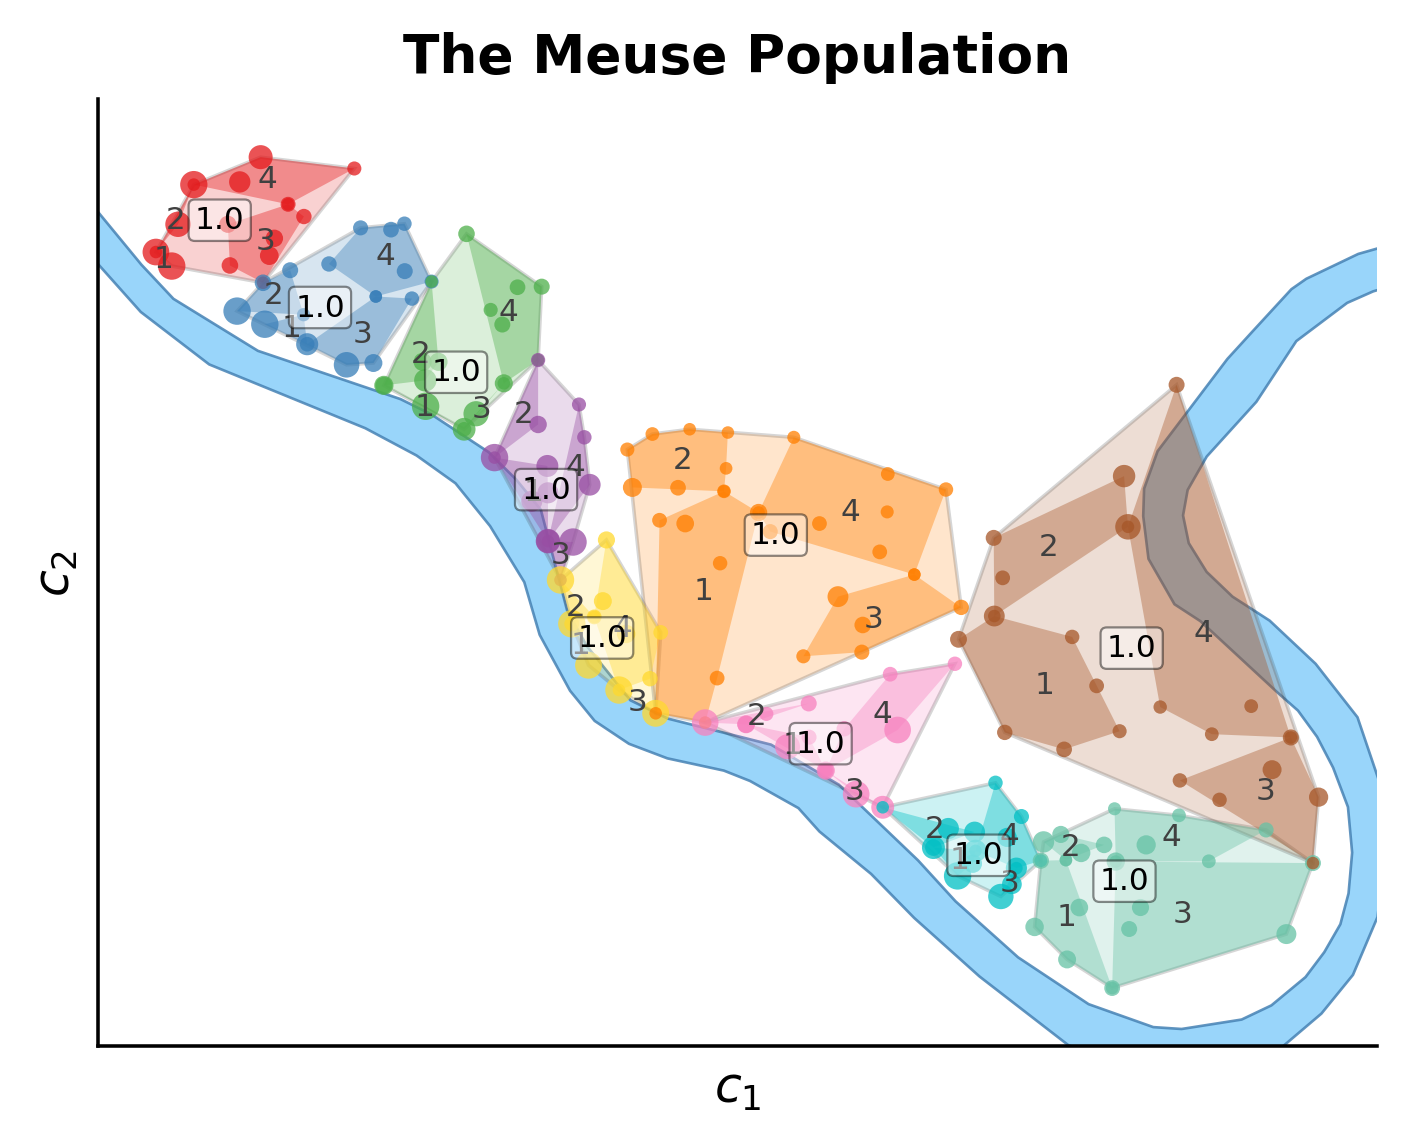

In [ ]:
# =========================================================
# PARAMETERS
# =========================================================

popu = "df_meuse"
ep_or_up = "pik_up"
n = 10

angle = 90   # use -90 for clockwise rotation

centroid_grid_x = 4
r_sample_per_cluster = 1

# =========================================================
# POPULATION
# =========================================================

df_raw = popus(n)[popu]
df = rotate_population(df_raw, angle, origin="center")

coords_data = df[["coord_x", "coord_y"]].to_numpy()
inclusions_data = df[ep_or_up].to_numpy()

pop = gs.Population(
    coords_data,
    inclusions_data,
    n=n
)

# =========================================================
# ROTATE AND NORMALIZE RIVER
# =========================================================

meuse_river_rot = rotate_gdf(
    meuse_river_gdf,
    angle,
    df_origin=df_raw
)

meuse_river_norm = normalize_gdf_like_population(
    meuse_river_rot,
    df
)

# =========================================================
# FIP-BALANCED N-MEANS
# =========================================================

fbn = gs.clustering.FIPBalancedNMeans(
    n=n,
    r_sample_per_cluster=r_sample_per_cluster,
    centroid_grid_x=centroid_grid_x,
    init_clust_method="expanded",
    split_size=0.0001
)

fbn.fit(pop)

fbn.fit_zones(
    num_zones=(2, 2),
    mode="sweep_xy"
)

# =========================================================
# PLOT
# =========================================================

fig, ax = plt.subplots(figsize=(7, 4), dpi=320)

fbn.plot(
    mode="soft",
    ax=ax,
    background_gdf=None,
    zone_color_mode=False,
    show_zone_sub_hulls=True,
    show_zone_labels=True,
    show_cluster_mass=True,
    size_scale=300,
    point_alpha=0.75,
    hull_alpha=0.20,
    zone_hull_alpha=0.38,
    point_size_min=8,
    point_size_max=38,
    show_centroids=False,
    connect_centroids=False
)

meuse_river_norm.plot(
    ax=ax,
    facecolor="lightskyblue",
    edgecolor="steelblue",
    linewidth=0.6,
    alpha=0.85,
    zorder=0.5
)
x = pop.coords[:, 0]
y = pop.coords[:, 1]
pad = 0.05

ax.set_xlim(x.min() - pad, x.max() + pad)
ax.set_ylim(y.min() - pad, y.max() + pad)

ax.set_title("The Meuse Population", fontsize=12, weight="bold")
ax.set_xlabel(r"$c_1$", fontsize=11)
ax.set_ylabel(r"$c_2$", fontsize=11)
ax.set_aspect("equal")

fig.subplots_adjust(
    left=0.10,
    right=0.98,
    bottom=0.14,
    top=0.88
)

fig.savefig("plots/meuse_fip_clusters_single.pdf", bbox_inches="tight", pad_inches=0.02)
fig.savefig("plots/meuse_fip_clusters_single.png", dpi=320, bbox_inches="tight", pad_inches=0.02)

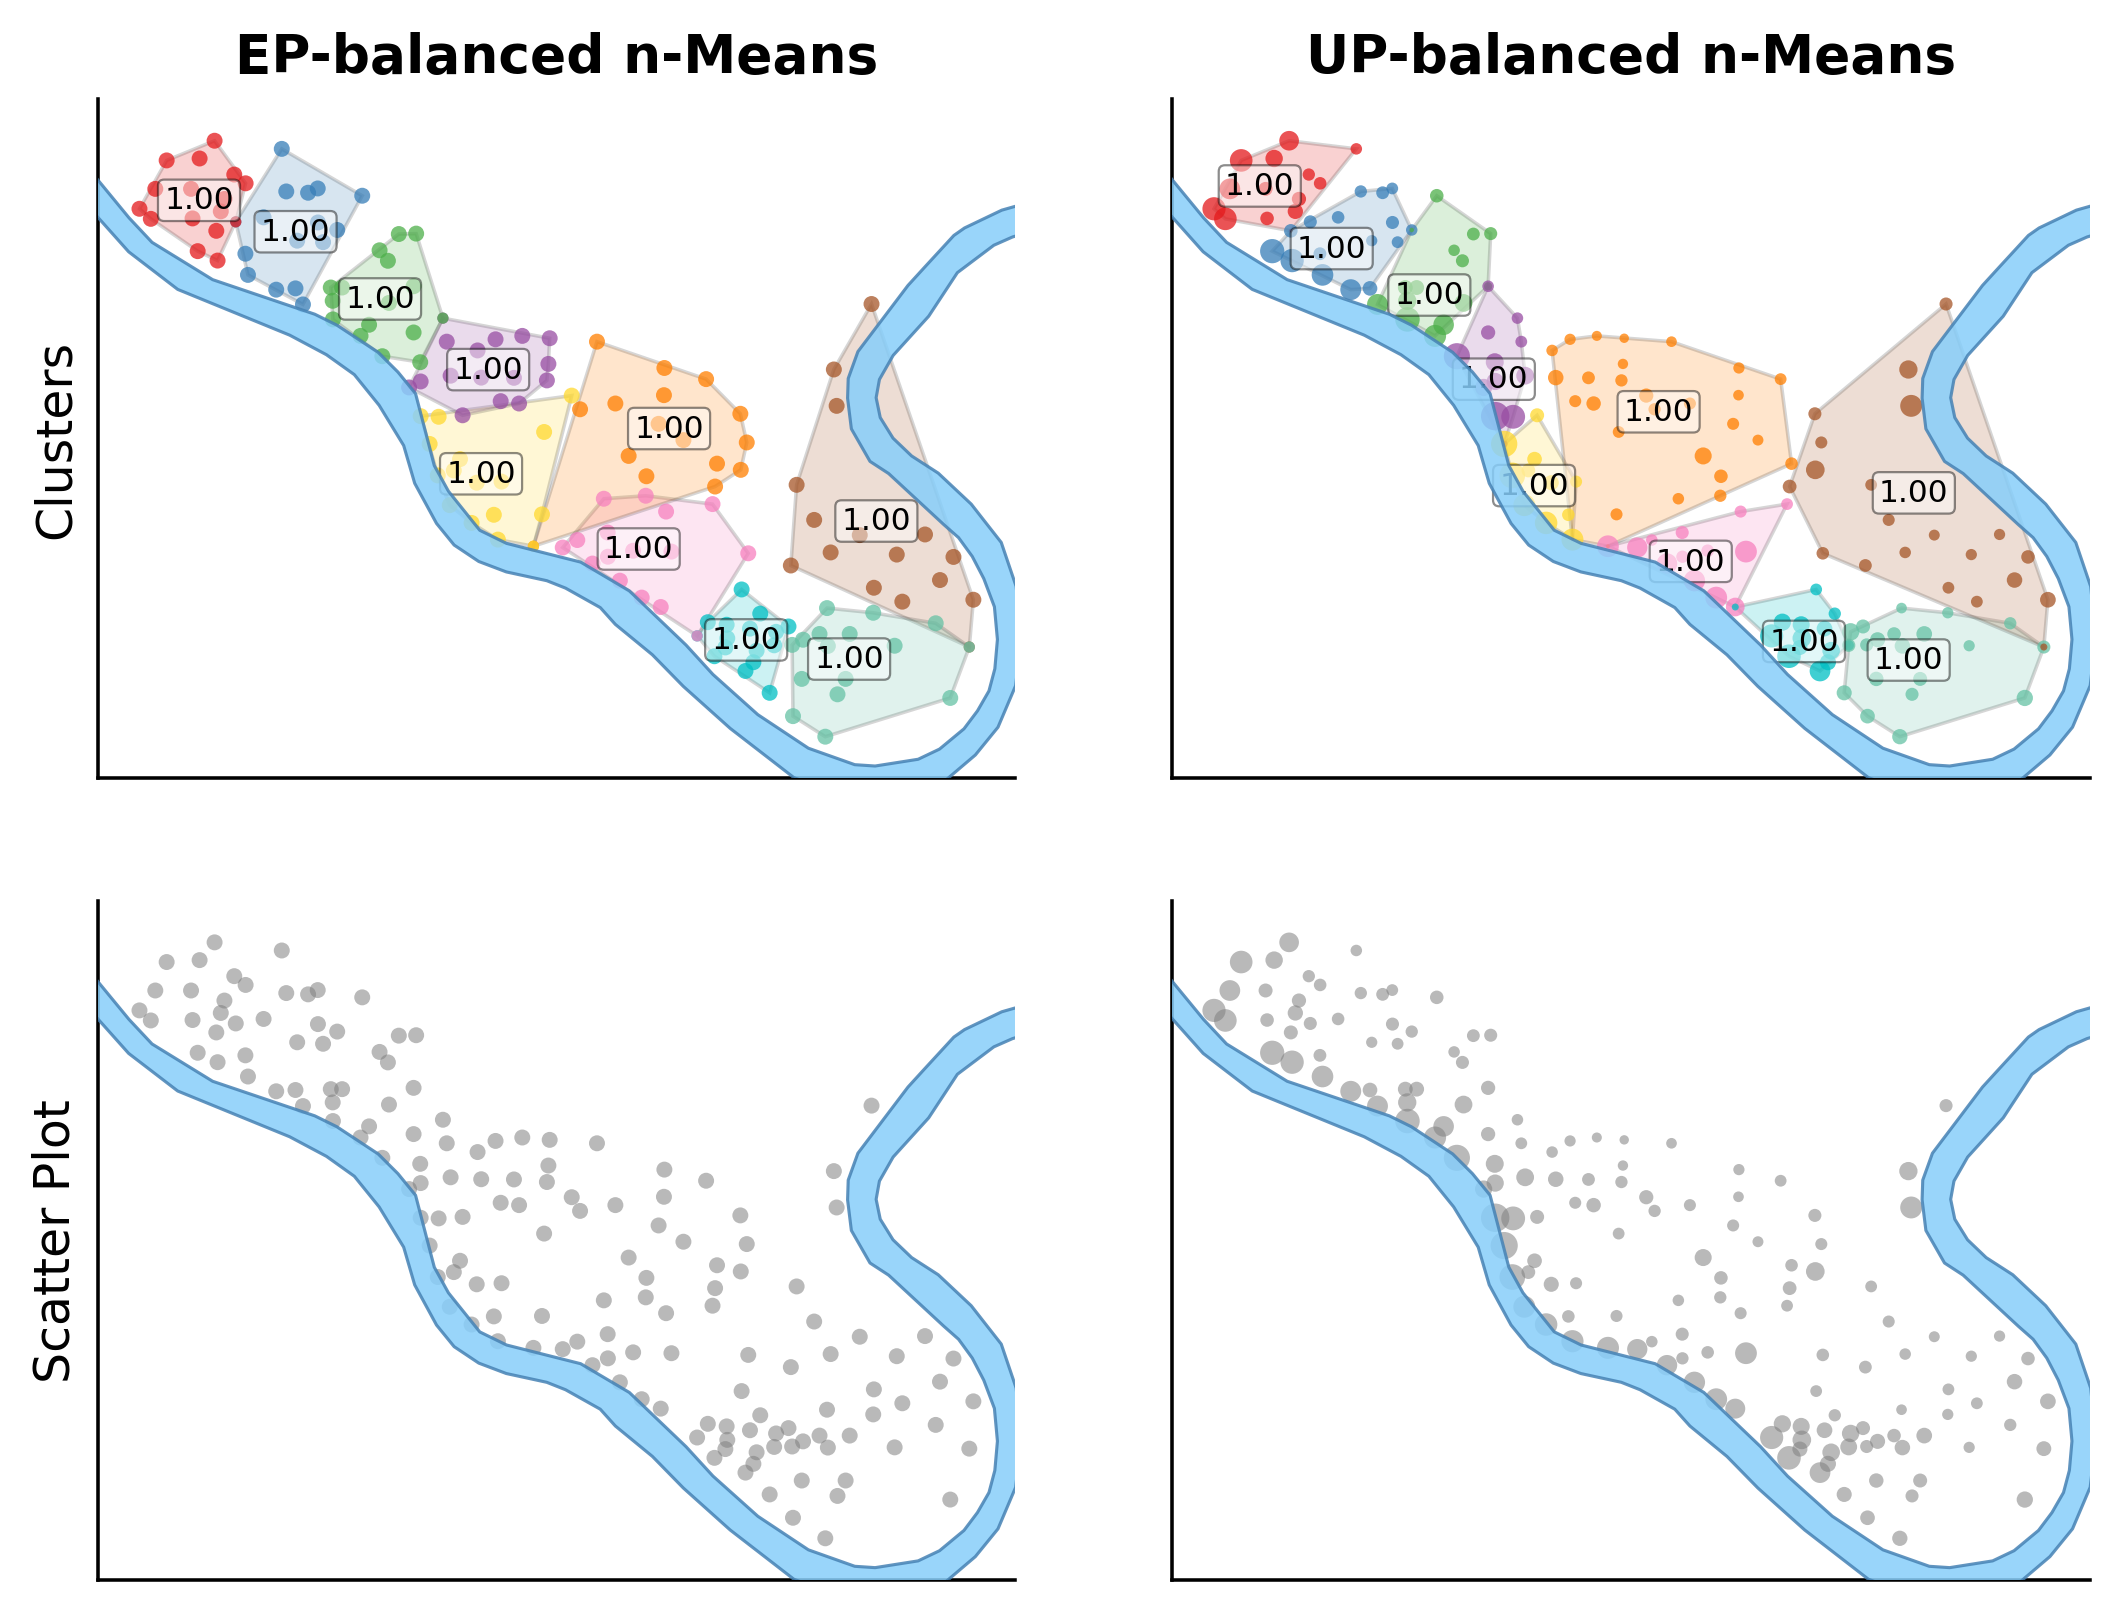

In [ ]:
# =========================================================
# PARAMETERS
# =========================================================

popu = "df_meuse"
n = 10

angle = 90   # use -90 for clockwise rotation

centroid_grid_x = 4
r_sample_per_cluster = 1

# =========================================================
# POPULATIONS
# =========================================================

df_raw = popus(n)[popu]

df_ep = rotate_population(df_raw, angle, origin="center")
df_up = rotate_population(df_raw, angle, origin="center")

coords_ep = df_ep[["coord_x", "coord_y"]].to_numpy()
pik_ep = df_ep["pik_ep"].to_numpy()

coords_up = df_up[["coord_x", "coord_y"]].to_numpy()
pik_up = df_up["pik_up"].to_numpy()

pop_ep = gs.Population(coords_ep, pik_ep, n=n)
pop_up = gs.Population(coords_up, pik_up, n=n)

# =========================================================
# ROTATE AND NORMALIZE RIVER
# =========================================================

meuse_river_rot = rotate_gdf(
    meuse_river_gdf,
    angle,
    df_origin=df_raw
)

meuse_river_norm = normalize_gdf_like_population(
    meuse_river_rot,
    df_up
)

# =========================================================
# EP-BALANCED N-MEANS
# =========================================================

fbn_ep = gs.clustering.FIPBalancedNMeans(
    n=n,
    r_sample_per_cluster=r_sample_per_cluster,
    centroid_grid_x=centroid_grid_x,
    init_clust_method="expanded",
    split_size=0.0001
)

fbn_ep.fit(pop_ep)

fbn_ep.fit_zones(
    num_zones=(1, 1),
    mode="sweep_xy"
)

# =========================================================
# UP-BALANCED N-MEANS
# =========================================================

fbn_up = gs.clustering.FIPBalancedNMeans(
    n=n,
    r_sample_per_cluster=r_sample_per_cluster,
    centroid_grid_x=centroid_grid_x,
    init_clust_method="expanded",
    split_size=0.0001
)

fbn_up.fit(pop_up)

fbn_up.fit_zones(
    num_zones=(1, 1),
    mode="sweep_xy"
)

# =========================================================
# HELPER: ADD MEUSE RIVER
# =========================================================

def add_meuse_river(ax, pop):
    meuse_river_norm.plot(
        ax=ax,
        facecolor="lightskyblue",
        edgecolor="steelblue",
        linewidth=0.7,
        alpha=0.85,
        zorder=60
    )

    x = pop.coords[:, 0]
    y = pop.coords[:, 1]
    pad = 0.05

    ax.set_xlim(x.min() - pad, x.max() + pad)
    ax.set_ylim(y.min() - pad, y.max() + pad)
# =========================================================
# FIGURE
# =========================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(7, 5.2),
    dpi=320,
    constrained_layout=False
)

ax11, ax12 = axes[0, 0], axes[0, 1]
ax21, ax22 = axes[1, 0], axes[1, 1]

# ---------------------------------------------------------
# Top-left: EP-balanced clusters
# ---------------------------------------------------------

fbn_ep.plot(
    mode="soft",
    ax=ax11,
    background_gdf=None,
    zone_color_mode=False,
    show_zone_sub_hulls=True,
    show_zone_labels=False,
    show_cluster_mass=True,
    size_scale=200,
    point_alpha=0.75,
    hull_alpha=0.20,
    zone_hull_alpha=0.38,
    point_size_min=0,
    point_size_max=10_000,
    show_centroids=False,
    connect_centroids=False
)

add_meuse_river(ax11, pop_ep)
ax11.set_title("EP-balanced n-Means", fontsize=12, weight="bold")

# ---------------------------------------------------------
# Top-right: UP-balanced clusters
# ---------------------------------------------------------

fbn_up.plot(
    mode="soft",
    ax=ax12,
    background_gdf=None,
    zone_color_mode=False,
    show_zone_sub_hulls=True,
    show_zone_labels=False,
    show_cluster_mass=True,
    size_scale=200,
    point_alpha=0.75,
    hull_alpha=0.20,
    zone_hull_alpha=0.38,
    point_size_min=0,
    point_size_max=10_000,
    show_centroids=False,
    connect_centroids=False
)

add_meuse_river(ax12, pop_up)
ax12.set_title("UP-balanced n-Means", fontsize=12, weight="bold")

# ---------------------------------------------------------
# Bottom-left: EP scatter plot
# ---------------------------------------------------------

ax21.scatter(
    pop_ep.coords[:, 0],
    pop_ep.coords[:, 1],
    s=200 * pop_ep.inclusions,
    color="gray",
    alpha=0.55,
    edgecolors="none",
    zorder=10
)

add_meuse_river(ax21, pop_ep)

# ---------------------------------------------------------
# Bottom-right: UP scatter plot
# ---------------------------------------------------------

ax22.scatter(
    pop_up.coords[:, 0],
    pop_up.coords[:, 1],
    s=200 * pop_up.inclusions,
    color="gray",
    alpha=0.55,
    edgecolors="none",
    zorder=10
)

add_meuse_river(ax22, pop_up)

# =========================================================
# CLEAN COMMON STYLE
# =========================================================

for ax in axes.ravel():
    ax.set_aspect("equal")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Keep only left-column row labels
ax11.set_ylabel("Clusters", fontsize=11)
ax21.set_ylabel("Scatter Plot", fontsize=11)

# No y-labels for second column
ax12.set_ylabel("")
ax22.set_ylabel("")

# =========================================================
# FINAL SPACING
# =========================================================

fig.subplots_adjust(
    left=0.04,
    right=0.99,
    bottom=0.04,
    top=0.93,
    wspace=0.02,
    hspace=0.18
)

fig.savefig("plots/meuse_fip_clusters.pdf", bbox_inches="tight")
fig.savefig("plots/meuse_fip_clusters.png", dpi=320, bbox_inches="tight")


plt.show()

### Spread Index Comparision

In [32]:
import os
import glob
import numpy as np
import pandas as pd
from IPython.display import display

# ============================================================
# Load and clean simulation summaries
# ============================================================

os.chdir("/home/bardia/projects/graphical-sampling/simulations")

RESULT_FOLDERS = {
    "Equal": "results/equal_M=5000",
    "Unequal": "results/unequal_M=5000",
}

COLS_TO_KEEP = [
    "Method", "N", "n",
    "Dm", "Ds",
    "Vm", "Vs",
    "Mm", "Ms",
    "Lm", "Ls",
]

NUMERIC_COLS = ["Dm", "Ds", "Vm", "Vs", "Mm", "Ms", "Lm", "Ls"]

METHOD_RENAME = {
    "Rand": "MAX",
    "Maxe": "MAX",
    "Scps": "SCP",
    "Lopi": "LPV",
    "Wave": "WAV",
    "GRZ": "GMS",
}

POPULATION_RENAME = {
    "clust": "Clustered",
    "rand": "Random",
    "grid": "Gridded",
}

all_dfs = []


def load_summary_files(folder_path, probability_label):
    """Load all summary CSV files from one folder and attach population/probability labels."""
    if not os.path.exists(folder_path):
        raise FileNotFoundError(f"Folder not found: {folder_path}")

    file_paths = sorted(glob.glob(os.path.join(folder_path, "summary_*.csv")))

    if not file_paths:
        raise FileNotFoundError(f"No summary_*.csv files found in: {folder_path}")

    for file_path in file_paths:
        df = pd.read_csv(file_path)

        available_cols = [col for col in COLS_TO_KEEP if col in df.columns]
        df = df[available_cols].copy()

        population_name = os.path.basename(file_path).split("_")[1]

        df.insert(0, "Population", population_name)
        df.insert(1, "Probability", probability_label)

        all_dfs.append(df)


# Load equal and unequal probability results
for probability_label, folder_path in RESULT_FOLDERS.items():
    load_summary_files(folder_path, probability_label)


# Combine all files
master_summary = pd.concat(all_dfs, ignore_index=True)

# Average duplicated rows if the same setting appears in multiple files
master_summary = (
    master_summary
    .groupby(["Population", "Probability", "Method", "n", "N"], as_index=False)[NUMERIC_COLS]
    .mean()
)

# Remove unwanted method/probability combinations
master_summary = master_summary[
    ~((master_summary["Probability"] == "Equal") & (master_summary["Method"] == "Maxe"))
]

master_summary = master_summary[
    ~((master_summary["Probability"] == "Unequal") & (master_summary["Method"] == "Rand"))
]

# Rename methods and populations
master_summary["Method"] = master_summary["Method"].replace(METHOD_RENAME)
master_summary["Population"] = master_summary["Population"].replace(POPULATION_RENAME)

# Clip L index values to avoid extreme display/reporting values
if "Lm" in master_summary.columns:
    master_summary["Lm"] = master_summary["Lm"].clip(lower=-1.5, upper=1.5)

if "Ls" in master_summary.columns:
    master_summary["Ls"] = master_summary["Ls"].clip(lower=-1.5, upper=1.5)

# Clean index
master_summary = master_summary.reset_index(drop=True)

# Save final cleaned summary
output_file = "results/modified_summary_new_pivotal.csv"
master_summary.to_csv(output_file, index=False)

# Display result
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

display(master_summary)

print(f"Saved cleaned summary to: {output_file}")
print(f"Methods: {sorted(master_summary['Method'].unique())}")
print(f"Populations: {sorted(master_summary['Population'].unique())}")

,Population,Probability,Method,n,N,Dm,Ds,Vm,Vs,Mm,Ms,Lm,Ls
0,Clustered,Equal,LPV,4.0,144.0,-0.009391,0.286982,0.153205,0.089442,-0.244573,0.129479,0.398958,0.090220
1,Clustered,Equal,LPV,8.0,144.0,-0.006147,0.155625,0.141389,0.072423,-0.279418,0.088735,0.223512,0.061206
2,Clustered,Equal,LPV,16.0,144.0,-0.011151,0.098023,0.184224,0.060531,-0.312942,0.077067,0.190123,0.034676
3,Clustered,Equal,LPV,32.0,144.0,-0.008697,0.057604,0.165909,0.042519,-0.412183,0.073641,0.128982,0.018501
4,Clustered,Equal,MAX,4.0,144.0,-0.245435,0.342724,0.301235,0.211779,-0.081180,0.121258,0.532737,0.153286
5,Clustered,Equal,MAX,8.0,144.0,-0.173571,0.315450,0.427871,0.274516,-0.049325,0.110435,0.393527,0.110135
6,Clustered,Equal,MAX,16.0,144.0,-0.094971,0.237259,0.455122,0.217867,-0.030893,0.105898,0.291665,0.060977
7,Clustered,Equal,MAX,32.0,144.0,-0.049808,0.160356,0.413388,0.145089,-0.016511,0.109097,0.199376,0.038187
8,Clustered,Equal,SCP,4.0,144.0,-0.004540,0.283679,0.146418,0.084877,-0.261152,0.123178,0.390428,0.088728
9,Clustered,Equal,SCP,8.0,144.0,-0.008020,0.155121,0.138425,0.072450,-0.308184,0.083863,0.222326,0.063057


Saved cleaned summary to: results/modified_summary_new_pivotal.csv
Methods: ['GMS', 'LPV', 'MAX', 'NMS', 'SCP', 'WAV']
Populations: ['Clustered', 'Gridded', 'Random', 'meuse', 'robertson', 'swiss']


In [40]:
# ============================================================
# Replace/add DI results: KMeans-based Dm/Ds -> n-medoids-based Dm/Ds
# Includes MAX, SCP, LPV, WAV, NMS, and GMS
# ============================================================

import pandas as pd
import numpy as np
from IPython.display import display
di_medoids_file = (
    "/home/bardia/projects/graphical-sampling/"
    "simulations/jupyters/results/DI_nmedoids_selected_populations.csv"
)
di_medoids = pd.read_csv(di_medoids_file)
print(di_medoids)
# ------------------------------------------------------------
# Methods whose DI values should be replaced/added
# ------------------------------------------------------------

target_methods = ["MAX", "SCP", "LPV", "WAV", "NMS", "GMS"]

merge_keys = ["Population", "Probability", "Method", "n", "N"]


# ------------------------------------------------------------
# Harmonization function
# ------------------------------------------------------------

def harmonize_names(df):
    df = df.copy()

    df["Population"] = df["Population"].replace({
        "clust_N144_perm": "Clustered",
        "grid_N144_perm": "Gridded",
        "grided_N144_perm": "Gridded",
        "rand_N144_perm": "Random",

        "Clustered": "Clustered",
        "Gridded": "Gridded",
        "Random": "Random",
        "meuse": "meuse",
        "swiss": "swiss",
    })

    df["Method"] = df["Method"].replace({
        "MaxEnt": "MAX",
        "Maxe": "MAX",
        "MAX": "MAX",

        "SPC": "SCP",
        "Scps": "SCP",
        "SCP": "SCP",

        "LPV": "LPV",
        "Lopi": "LPV",

        "WAV": "WAV",
        "Wave": "WAV",

        "NMS": "NMS",
        "GMS": "GMS",
    })

    df["Probability"] = df["Probability"].replace({
        "UP": "Unequal",
        "EP": "Equal",
        "Unequal": "Unequal",
        "Equal": "Equal",
    })

    return df


# ------------------------------------------------------------
# Harmonize both tables
# ------------------------------------------------------------

di_medoids = harmonize_names(di_medoids)
master_summary = harmonize_names(master_summary)

# Ensure n and N have the same type in both tables
for col in ["n", "N"]:
    di_medoids[col] = pd.to_numeric(di_medoids[col], errors="coerce").astype(int)
    master_summary[col] = pd.to_numeric(master_summary[col], errors="coerce").astype(int)


# ------------------------------------------------------------
# Keep only needed DI columns
# ------------------------------------------------------------

di_medoids = di_medoids[
    ["Population", "Probability", "Method", "n", "N", "Dm", "Ds"]
].copy()

di_medoids = di_medoids.rename(columns={
    "Dm": "Dm_nmedoids",
    "Ds": "Ds_nmedoids",
})

# Avoid duplicated keys
dup_mask = di_medoids.duplicated(merge_keys, keep=False)

if dup_mask.any():
    print("Warning: duplicated rows found in di_medoids. Keeping the last one for each key.")
    display(di_medoids.loc[dup_mask].sort_values(merge_keys))

di_medoids = di_medoids.drop_duplicates(merge_keys, keep="last")


# ------------------------------------------------------------
# Backup old KMeans-based DI values only once
# ------------------------------------------------------------

if "Dm_kmeans" not in master_summary.columns:
    master_summary["Dm_kmeans"] = master_summary["Dm"]

if "Ds_kmeans" not in master_summary.columns:
    master_summary["Ds_kmeans"] = master_summary["Ds"]


# ------------------------------------------------------------
# Identify rows that are not already in master_summary
# This is needed if NMS/GMS rows are absent from master_summary
# ------------------------------------------------------------

existing_keys = master_summary[merge_keys].drop_duplicates()

missing_rows = di_medoids.merge(
    existing_keys,
    on=merge_keys,
    how="left",
    indicator=True,
)

missing_rows = missing_rows.loc[
    missing_rows["_merge"] == "left_only"
].drop(columns="_merge")


# ------------------------------------------------------------
# Merge n-medoids DI values into existing master_summary rows
# ------------------------------------------------------------

# Remove helper columns if the cell was run before
for col in ["Dm_nmedoids", "Ds_nmedoids"]:
    if col in master_summary.columns:
        master_summary = master_summary.drop(columns=[col])

master_summary = master_summary.merge(
    di_medoids,
    on=merge_keys,
    how="left",
)

replace_mask = (
    master_summary["Dm_nmedoids"].notna()
    & master_summary["Ds_nmedoids"].notna()
)

master_summary.loc[replace_mask, "Dm"] = master_summary.loc[replace_mask, "Dm_nmedoids"]
master_summary.loc[replace_mask, "Ds"] = master_summary.loc[replace_mask, "Ds_nmedoids"]


# ------------------------------------------------------------
# Remove helper n-medoids columns, but keep KMeans backups
# ------------------------------------------------------------

master_summary = master_summary.drop(columns=["Dm_nmedoids", "Ds_nmedoids"])


# ------------------------------------------------------------
# Append missing rows, if any
# This will add NMS/GMS rows if they were not already present
# ------------------------------------------------------------

if len(missing_rows) > 0:
    new_rows = missing_rows.rename(columns={
        "Dm_nmedoids": "Dm",
        "Ds_nmedoids": "Ds",
    })

    new_rows["Dm_kmeans"] = np.nan
    new_rows["Ds_kmeans"] = np.nan

    # Add missing columns as NA so the table structure matches master_summary
    for col in master_summary.columns:
        if col not in new_rows.columns:
            new_rows[col] = np.nan

    # If new_rows has extra columns not in master_summary, add them to master_summary
    for col in new_rows.columns:
        if col not in master_summary.columns:
            master_summary[col] = np.nan

    master_summary = pd.concat(
        [master_summary, new_rows[master_summary.columns]],
        ignore_index=True,
    )


# ------------------------------------------------------------
# Check replacement/addition
# ------------------------------------------------------------

print(f"Number of existing Dm/Ds rows replaced by n-medoids results: {replace_mask.sum()}")
print(f"Number of new rows appended from n-medoids results: {len(missing_rows)}")
print(f"Total n-medoids rows used: {replace_mask.sum() + len(missing_rows)}")
print(f"Total rows in master_summary after update: {len(master_summary)}")

not_replaced = master_summary.loc[
    master_summary["Method"].isin(target_methods)
    & master_summary["Dm"].isna()
    & master_summary["Ds"].isna(),
    merge_keys
].drop_duplicates()

if len(not_replaced) > 0:
    print("\nRows still without Dm/Ds:")
    display(not_replaced)
else:
    print("All available MAX/SCP/LPV/WAV/NMS/GMS Dm/Ds rows were replaced or added successfully.")


# ------------------------------------------------------------
# Display final table
# ------------------------------------------------------------

display(master_summary)


# ------------------------------------------------------------
# Optional: save updated master summary
# ------------------------------------------------------------

output_file = (
    "/home/bardia/projects/graphical-sampling/"
    "simulations/results/master_summary_DI_nmedoids_updated.csv"
)

master_summary.to_csv(output_file, index=False)

print(f"\nSaved updated master_summary to:\n{output_file}")

    Population Probability Method    n    N        Dm        Ds
0    Clustered          UP    MAX    4  144 -0.222011  0.323966
1    Clustered          UP    SCP    4  144 -0.097165  0.250533
2    Clustered          UP    LPV    4  144 -0.099182  0.247578
3    Clustered          UP    WAV    4  144 -0.093114  0.234748
4    Clustered          UP    MAX    8  144 -0.118952  0.279499
5    Clustered          UP    SCP    8  144  0.017536  0.146823
6    Clustered          UP    LPV    8  144  0.013083  0.142689
7    Clustered          UP    WAV    8  144  0.014995  0.132388
8    Clustered          UP    MAX   16  144 -0.037762  0.227420
9    Clustered          UP    SCP   16  144 -0.022541  0.115969
10   Clustered          UP    LPV   16  144 -0.023584  0.112030
11   Clustered          UP    WAV   16  144 -0.013183  0.119704
12   Clustered          UP    MAX   32  144 -0.013262  0.152941
13   Clustered          UP    SCP   32  144 -0.011374  0.056775
14   Clustered          UP    LPV   32  

,Population,Probability,Method,n,N,Dm,Ds,Vm,Vs,Mm,Ms,Lm,Ls,Dm_kmeans,Ds_kmeans
0,Clustered,Equal,LPV,4,144,-0.076606,0.242736,0.153205,0.089442,-0.244573,0.129479,0.398958,0.090220,-0.009391,0.286982
1,Clustered,Equal,LPV,8,144,0.001261,0.140450,0.141389,0.072423,-0.279418,0.088735,0.223512,0.061206,-0.006147,0.155625
2,Clustered,Equal,LPV,16,144,-0.019340,0.099662,0.184224,0.060531,-0.312942,0.077067,0.190123,0.034676,-0.011151,0.098023
3,Clustered,Equal,LPV,32,144,-0.005514,0.060230,0.165909,0.042519,-0.412183,0.073641,0.128982,0.018501,-0.008697,0.057604
4,Clustered,Equal,MAX,4,144,-0.191394,0.315444,0.301235,0.211779,-0.081180,0.121258,0.532737,0.153286,-0.245435,0.342724
5,Clustered,Equal,MAX,8,144,-0.136025,0.271449,0.427871,0.274516,-0.049325,0.110435,0.393527,0.110135,-0.173571,0.315450
6,Clustered,Equal,MAX,16,144,-0.047061,0.233404,0.455122,0.217867,-0.030893,0.105898,0.291665,0.060977,-0.094971,0.237259
7,Clustered,Equal,MAX,32,144,-0.027048,0.156155,0.413388,0.145089,-0.016511,0.109097,0.199376,0.038187,-0.049808,0.160356
8,Clustered,Equal,SCP,4,144,-0.062978,0.247355,0.146418,0.084877,-0.261152,0.123178,0.390428,0.088728,-0.004540,0.283679
9,Clustered,Equal,SCP,8,144,-0.018024,0.145556,0.138425,0.072450,-0.308184,0.083863,0.222326,0.063057,-0.008020,0.155121



Saved updated master_summary to:
/home/bardia/projects/graphical-sampling/simulations/results/master_summary_DI_nmedoids_updated.csv


#### Sampling Designs

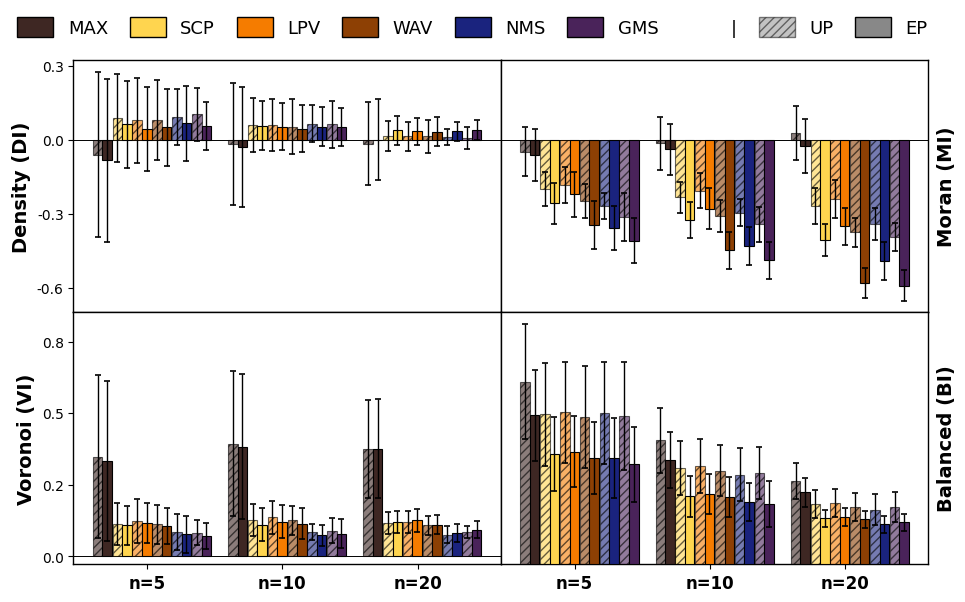

ValueError: cannot reindex on an axis with duplicate labels

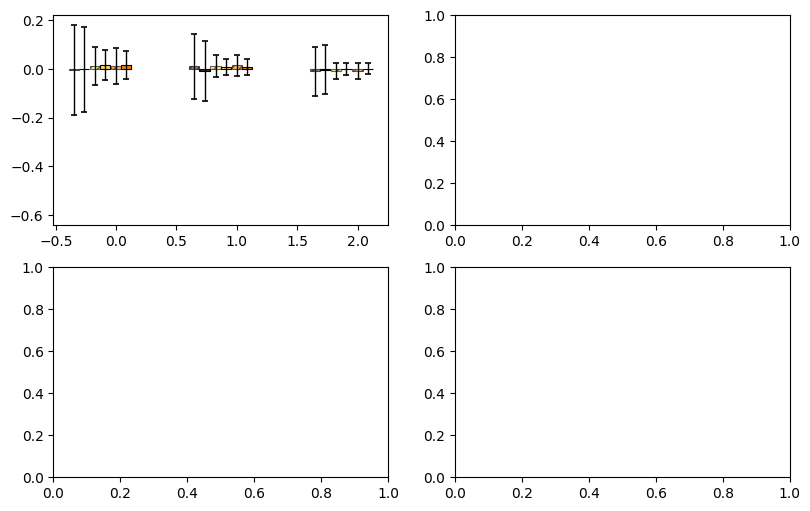

In [41]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter
import numpy as np
import os


def plot_real_meuse_style(dataset_name, save_plot=False):
    """
    Reproduce the exact 'Meuse–Swiss synthetic-style' visualization
    for real populations (Meuse or Switzerland Amphibians).
    """

    # ---------- Metrics, Colors, Settings ----------
    metrics = [
        ('Dm', 'Ds', 'Density (DI)'),
        ('Mm', 'Ms', 'Moran (MI)'),
        ('Vm', 'Vs', 'Voronoi (VI)'),
        ('Lm', 'Ls', 'Balanced (BI)')
    ]

    all_methods = ['MAX', 'SCP', 'LPV', 'WAV', 'NMS', 'GMS']

    color_dict = {
        'MAX': '#3E2723',
        'SCP': '#FFD54F',
        'LPV': '#F57C00',
        'WAV': '#8D4004',
        'NMS': '#1A237E',
        'GMS': '#4A235A'
    }

    # Error bar colors (same as synthetic)
    # EP_ERR = '#8B1E3F'   # red‑tone for EP
    # UP_ERR = '#1B3A6F'   # blue‑tone for UP

    UP_ERR = "#2E86DE"   # clear cobalt blue
    EP_ERR = "#2ECC71"   # fresh emerald green
    elinewidth = 1.6
    capsize = 3
    UP_ERR = "black"   # clear cobalt blue
    EP_ERR = "black"   # fresh emerald green
    elinewidth = 1
    capsize = 2

    fig, axes = plt.subplots(
        nrows=2, ncols=2, figsize=(9.5, 6),
        sharex=False
    )
    axes = axes.flatten()

    # Figure title (depends on dataset)
    if dataset_name.lower() == 'meuse':
        title_text = "The Meuse Population"
    else:
        title_text = "The Switzerland Amphibians Population"

    # fig.suptitle(
    #     title_text,
    #     fontsize=15,
    #     fontweight='bold',
    #     y=0.995
    # )

    # ---------- Retrieve Dataset ----------
    pop_data = master_summary[master_summary['Population'] == dataset_name]

    if pop_data.empty:
        print("No data for", dataset_name)
        return

    active_methods = [m for m in all_methods if m in pop_data["Method"].unique()]
    n_vals = sorted(pop_data['n'].unique())
    x_pos = np.arange(len(n_vals))

    # ---------- Style Constants (shared with synthetic plot) ----------
    total_group_width = 0.88
    method_width = total_group_width / len(active_methods)
    bar_width = method_width * 0.48

    # ---------- Determine Shared y-limits per metric row ----------
    # DI + MI rows share limits
    di_mi_ymin, di_mi_ymax = np.inf, -np.inf
    for col_mean, col_std, _ in metrics[:2]:
        low = (pop_data[col_mean] - pop_data[col_std]).min()
        high = (pop_data[col_mean] + pop_data[col_std]).max()
        di_mi_ymin, di_mi_ymax = min(di_mi_ymin, low), max(di_mi_ymax, high)
    pad = 0.05 * (di_mi_ymax - di_mi_ymin)
    di_mi_ymin -= pad
    di_mi_ymax += pad

    # VI + BI rows share limits
    vi_bi_ymin, vi_bi_ymax = np.inf, -np.inf
    for col_mean, col_std, _ in metrics[2:]:
        low = (pop_data[col_mean] - pop_data[col_std]).min()
        high = (pop_data[col_mean] + pop_data[col_std]).max()
        vi_bi_ymin, vi_bi_ymax = min(vi_bi_ymin, low), max(vi_bi_ymax, high)
    pad = 0.05 * (vi_bi_ymax - vi_bi_ymin)
    vi_bi_ymin -= pad
    vi_bi_ymax += pad

    # ---------- Plotting Loop ----------
    for idx, (mean_col, std_col, metric_name) in enumerate(metrics):
        ax = axes[idx]

        # Determine y-limits for this metric
        if idx < 2:
            ymin, ymax = di_mi_ymin, di_mi_ymax
        else:
            ymin, ymax = vi_bi_ymin, vi_bi_ymax
        if metric_name == 'Balanced (BI)':
            ymin = 0
        ax.set_ylim(ymin, ymax)

        # Plot per method (side by side bars for UP/EP)
        for i, method in enumerate(active_methods):
            m_data = pop_data[pop_data["Method"] == method]
            up_data = (
                m_data[m_data["Probability"] == "Unequal"]
                .set_index("n")
                .reindex(n_vals)
            )
            ep_data = (
                m_data[m_data["Probability"] == "Equal"]
                .set_index("n")
                .reindex(n_vals)
            )

            offset = (i - len(active_methods) / 2 + 0.5) * method_width

            # --- Unequal Probability (solid) ---
            error_style_up = dict(
                    ecolor=UP_ERR,    # color of error bar
                    elinewidth=elinewidth,    # thickness of the bar
                    capsize=capsize,         # width of the cap
                    capthick=1.2       # thickness of the cap
                )
            # error_style_up = dict(
            #     ecolor=UP_ERR, elinewidth=0.6, capsize=2.5, capthick=1.2
            # )
            ax.bar(
                x_pos + offset,
                up_data[mean_col].values,
                bar_width,
                yerr=up_data[std_col].values if std_col in up_data.columns else 0,
                color=color_dict[method],
                edgecolor="black",
                alpha=.6,
                hatch="////",
                linewidth=0.8,
                error_kw=error_style_up,
                zorder=3
            )

            # --- Equal Probability (hatched) ---
            error_style_ep = dict(
                    ecolor=EP_ERR,    # color of error bar
                    elinewidth=elinewidth,    # thickness of the bar
                    capsize=capsize,         # width of the cap
                    capthick=1.2       # thickness of the cap
                )
            # error_style_ep = dict(
            #     ecolor=EP_ERR, elinewidth=0.6, capsize=2.5, capthick=1.2
            # )
            ax.bar(
                x_pos + offset + bar_width,
                ep_data[mean_col].values,
                bar_width,
                yerr=ep_data[std_col].values if std_col in ep_data.columns else 0,
                color=color_dict[method],
                edgecolor="black",
                alpha=1,
                linewidth=0.8,
                error_kw=error_style_ep,
                zorder=3
            )

        # ---------- Axes, Labels, Grid ----------
        ax.axhline(0, color="black", linewidth=0.7)
        ax.grid(False)

        ax.set_xticks(x_pos)
        ax.set_xticklabels([f"n={int(n)}" for n in n_vals],
                           fontsize=12, fontweight="bold")

        # Column and row labeling (same structure)
        if idx in (0, 2):  # left column: show ylabel
            ax.set_ylabel(metric_name, fontsize=14, fontweight="bold")
            ax.tick_params(axis='y', labelsize=10)
            ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=4))
            ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
        else:
            ax.set_yticklabels([])
            ax.set_yticks([])

        if idx == 1:  # Moran
            ax.text(1.02, 0.5, 'Moran (MI)',
                    transform=ax.transAxes,
                    rotation=90,
                    fontsize=14, fontweight='bold',
                    va='center', ha='left')
        elif idx == 3:  # Balanced
                ax.text(1.02, 0.5, 'Balanced (BI)',
                        transform=ax.transAxes,
                        rotation=90,
                        fontsize=14, fontweight='bold',
                        va='center', ha='left')

        # X-labels only bottom row
        if idx in (0, 1):
            ax.set_xticklabels([])

        # Subplot border line color/width
        for spine in ax.spines.values():
            spine.set_linewidth(1.0)
            # spine.set_color('black')  # normally light gray in original Meuse–Swiss

    # ---------- Legend (identical styling) ----------
    # ---------- Legend ----------
    method_legend = [
        mpatches.Patch(
            facecolor=color_dict[m],
            edgecolor="black",
            label=m
        )
        for m in active_methods
    ]

    spacer = mpatches.Patch(
        facecolor="none",
        edgecolor="none",
        label="|"
    )

    prob_legend = [
        mpatches.Patch(
            facecolor="#888888",
            edgecolor="black",
            hatch="////",
            alpha=0.5,
            label="UP"
        ),
        mpatches.Patch(
            facecolor="#888888",
            edgecolor="black",
            alpha=1.0,
            label="EP"
        )
    ]

    legend_elements = method_legend + [spacer] + prob_legend

    fig.legend(
        handles=legend_elements,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.99),
        ncol=len(legend_elements),
        frameon=False,
        fontsize=13,
        handlelength=2.0,
        handleheight=1.4,
        columnspacing=1.2
)

    
    

    # ---------- Layout ----------
    plt.subplots_adjust(
        left=0.08,
        right=0.98,
        top=0.89,
        bottom=0.05,
        wspace=0.0,
        hspace=0.0
    )
#     fig.suptitle(
#     title_text,
#     fontsize=15,
#     fontweight="bold",
#     y=1.03
# )

    # ---------- Save and Show ----------
    
    fname = dataset_name.lower()
    fig.savefig(
        f"plots/{fname}_balance_indices_sampling.pdf",
        bbox_inches="tight",
        pad_inches=0.04
    )
    fig.savefig(
        f"plots/{fname}_balance_indices_sampling.png",
        dpi=320,
        bbox_inches="tight",
        pad_inches=0.02
    )

    plt.show()
plot_real_meuse_style("meuse", save_plot=True)
plot_real_meuse_style("swiss", save_plot=True)

#### Measure DI

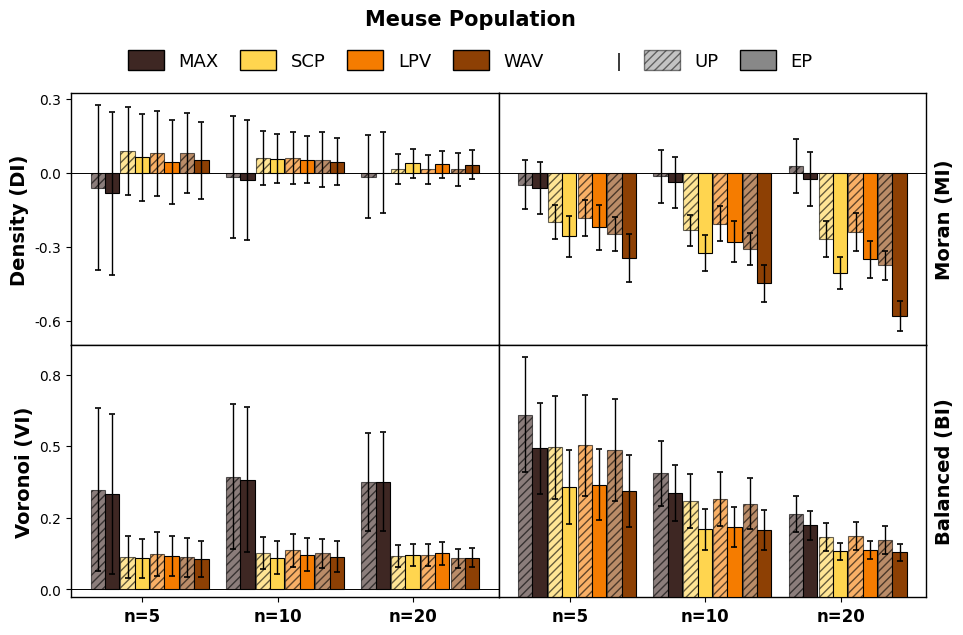

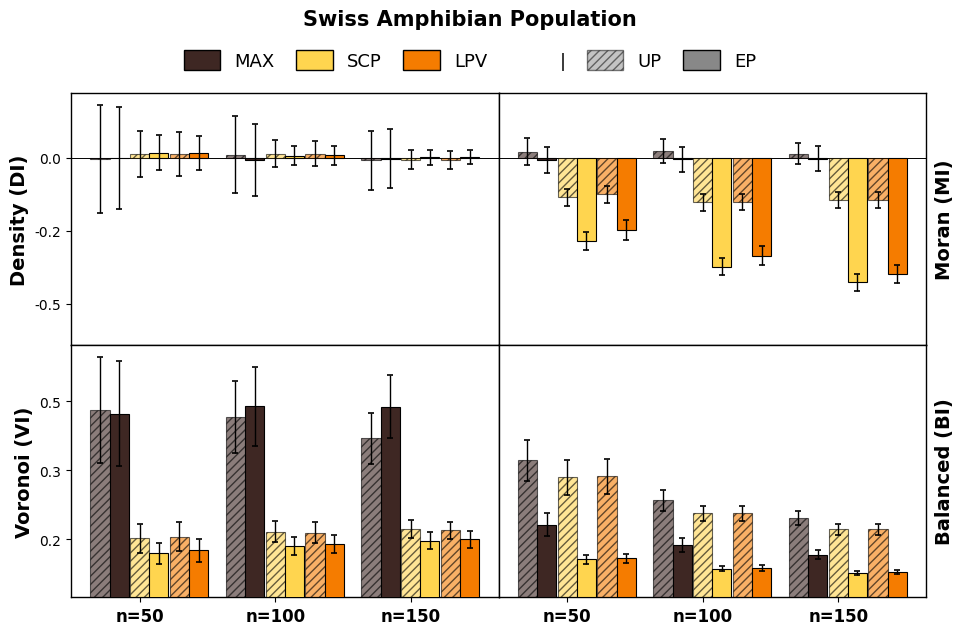

In [28]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter
import numpy as np
import os


def plot_real_meuse_style(dataset_name, save_plot=False):
    """
    Reproduce the exact 'Meuse–Swiss synthetic-style' visualization
    for real populations (Meuse or Switzerland Amphibians).
    """

    # ---------- Metrics, Colors, Settings ----------
    metrics = [
        ('Dm', 'Ds', 'Density (DI)'),
        ('Mm', 'Ms', 'Moran (MI)'),
        ('Vm', 'Vs', 'Voronoi (VI)'),
        ('Lm', 'Ls', 'Balanced (BI)')
    ]

    all_methods = ['MAX', 'SCP', 'LPV', 'WAV']

    color_dict = {
        'MAX': '#3E2723',
        'SCP': '#FFD54F',
        'LPV': '#F57C00',
        'WAV': '#8D4004',
        'NMS': '#1A237E',
        'GRZ': '#4A235A'
    }

    # Error bar colors (same as synthetic)
    # EP_ERR = '#8B1E3F'   # red‑tone for EP
    # UP_ERR = '#1B3A6F'   # blue‑tone for UP

    UP_ERR = "#2E86DE"   # clear cobalt blue
    EP_ERR = "#2ECC71"   # fresh emerald green
    elinewidth = 1.6
    capsize = 3
    UP_ERR = "black"   # clear cobalt blue
    EP_ERR = "black"   # fresh emerald green
    elinewidth = 1
    capsize = 2

    fig, axes = plt.subplots(
        nrows=2, ncols=2, figsize=(9.5, 6),
        sharex=False
    )
    axes = axes.flatten()

    # Figure title (depends on dataset)
    if dataset_name.lower() == 'meuse':
        title_text = "Meuse Population"
    else:
        title_text = "Swiss Amphibian Population"

    fig.suptitle(
        title_text,
        fontsize=15,
        fontweight='bold',
        y=0.995
    )

    # ---------- Retrieve Dataset ----------
    pop_data = master_summary[master_summary['Population'] == dataset_name]

    if pop_data.empty:
        print("No data for", dataset_name)
        return

    active_methods = [m for m in all_methods if m in pop_data["Method"].unique()]
    n_vals = sorted(pop_data['n'].unique())
    x_pos = np.arange(len(n_vals))

    # ---------- Style Constants (shared with synthetic plot) ----------
    total_group_width = 0.88
    method_width = total_group_width / len(active_methods)
    bar_width = method_width * 0.48

    # ---------- Determine Shared y-limits per metric row ----------
    # DI + MI rows share limits
    di_mi_ymin, di_mi_ymax = np.inf, -np.inf
    for col_mean, col_std, _ in metrics[:2]:
        low = (pop_data[col_mean] - pop_data[col_std]).min()
        high = (pop_data[col_mean] + pop_data[col_std]).max()
        di_mi_ymin, di_mi_ymax = min(di_mi_ymin, low), max(di_mi_ymax, high)
    pad = 0.05 * (di_mi_ymax - di_mi_ymin)
    di_mi_ymin -= pad
    di_mi_ymax += pad

    # VI + BI rows share limits
    vi_bi_ymin, vi_bi_ymax = np.inf, -np.inf
    for col_mean, col_std, _ in metrics[2:]:
        low = (pop_data[col_mean] - pop_data[col_std]).min()
        high = (pop_data[col_mean] + pop_data[col_std]).max()
        vi_bi_ymin, vi_bi_ymax = min(vi_bi_ymin, low), max(vi_bi_ymax, high)
    pad = 0.05 * (vi_bi_ymax - vi_bi_ymin)
    vi_bi_ymin -= pad
    vi_bi_ymax += pad

    # ---------- Plotting Loop ----------
    for idx, (mean_col, std_col, metric_name) in enumerate(metrics):
        ax = axes[idx]

        # Determine y-limits for this metric
        if idx < 2:
            ymin, ymax = di_mi_ymin, di_mi_ymax
        else:
            ymin, ymax = vi_bi_ymin, vi_bi_ymax
        if metric_name == 'Balanced (BI)':
            ymin = 0
        ax.set_ylim(ymin, ymax)

        # Plot per method (side by side bars for UP/EP)
        for i, method in enumerate(active_methods):
            m_data = pop_data[pop_data["Method"] == method]
            up_data = (
                m_data[m_data["Probability"] == "Unequal"]
                .set_index("n")
                .reindex(n_vals)
            )
            ep_data = (
                m_data[m_data["Probability"] == "Equal"]
                .set_index("n")
                .reindex(n_vals)
            )

            offset = (i - len(active_methods) / 2 + 0.5) * method_width

            # --- Unequal Probability (solid) ---
            error_style_up = dict(
                    ecolor=UP_ERR,    # color of error bar
                    elinewidth=elinewidth,    # thickness of the bar
                    capsize=capsize,         # width of the cap
                    capthick=1.2       # thickness of the cap
                )
            # error_style_up = dict(
            #     ecolor=UP_ERR, elinewidth=0.6, capsize=2.5, capthick=1.2
            # )
            ax.bar(
                x_pos + offset,
                up_data[mean_col].values,
                bar_width,
                yerr=up_data[std_col].values if std_col in up_data.columns else 0,
                color=color_dict[method],
                edgecolor="black",
                alpha=.6,
                hatch="////",
                linewidth=0.8,
                error_kw=error_style_up,
                zorder=3
            )

            # --- Equal Probability (hatched) ---
            error_style_ep = dict(
                    ecolor=EP_ERR,    # color of error bar
                    elinewidth=elinewidth,    # thickness of the bar
                    capsize=capsize,         # width of the cap
                    capthick=1.2       # thickness of the cap
                )
            # error_style_ep = dict(
            #     ecolor=EP_ERR, elinewidth=0.6, capsize=2.5, capthick=1.2
            # )
            ax.bar(
                x_pos + offset + bar_width,
                ep_data[mean_col].values,
                bar_width,
                yerr=ep_data[std_col].values if std_col in ep_data.columns else 0,
                color=color_dict[method],
                edgecolor="black",
                alpha=1,
                linewidth=0.8,
                error_kw=error_style_ep,
                zorder=3
            )

        # ---------- Axes, Labels, Grid ----------
        ax.axhline(0, color="black", linewidth=0.7)
        ax.grid(False)

        ax.set_xticks(x_pos)
        ax.set_xticklabels([f"n={int(n)}" for n in n_vals],
                           fontsize=12, fontweight="bold")

        # Column and row labeling (same structure)
        if idx in (0, 2):  # left column: show ylabel
            ax.set_ylabel(metric_name, fontsize=14, fontweight="bold")
            ax.tick_params(axis='y', labelsize=10)
            ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=4))
            ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
        else:
            ax.set_yticklabels([])
            ax.set_yticks([])

        if idx == 1:  # Moran
            ax.text(1.02, 0.5, 'Moran (MI)',
                    transform=ax.transAxes,
                    rotation=90,
                    fontsize=14, fontweight='bold',
                    va='center', ha='left')
        elif idx == 3:  # Balanced
                ax.text(1.02, 0.5, 'Balanced (BI)',
                        transform=ax.transAxes,
                        rotation=90,
                        fontsize=14, fontweight='bold',
                        va='center', ha='left')

        # X-labels only bottom row
        if idx in (0, 1):
            ax.set_xticklabels([])

        # Subplot border line color/width
        for spine in ax.spines.values():
            spine.set_linewidth(1.0)
            # spine.set_color('black')  # normally light gray in original Meuse–Swiss

    # ---------- Legend (identical styling) ----------
    method_legend = [
        mpatches.Patch(
            facecolor=color_dict[m],
            edgecolor="black",
            label=m
        )
        for m in active_methods
    ]

    spacer = mpatches.Patch(
        facecolor="none",
        edgecolor="none",
        label="|"
    )

    prob_legend = [
        mpatches.Patch(
            facecolor="#888888",
            edgecolor="black",
            hatch="////",
            alpha=0.5,
            label="UP"
        ),
        mpatches.Patch(
            facecolor="#888888",
            edgecolor="black",
            alpha=1.0,
            label="EP"
        )
    ]

    legend_elements = method_legend + [spacer] + prob_legend

    fig.legend(
        handles=legend_elements,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.99),
        ncol=len(legend_elements),
        frameon=False,
        fontsize=13,
        handlelength=2.0,
        handleheight=1.4,
        columnspacing=1.2
    )
    
    

    # ---------- Layout ----------
    plt.subplots_adjust(
        left=0.08,
        right=0.98,
        top=0.89,
        bottom=0.05,
        wspace=0.0,
        hspace=0.0
    )
    fig.suptitle(
    title_text,
    fontsize=15,
    fontweight="bold",
    y=1.03
)

    # ---------- Save and Show ----------
    
    fname = dataset_name.lower()
    fig.savefig(
        f"plots/{fname}_balance_indices_measure.pdf",
        bbox_inches="tight",
        pad_inches=0.04
    )
    fig.savefig(
        f"plots/{fname}_balance_indices_measure.png",
        dpi=320,
        bbox_inches="tight",
        pad_inches=0.02
    )

    plt.show()
plot_real_meuse_style("meuse", save_plot=True)
plot_real_meuse_style("swiss", save_plot=True)

Saved:
- plots/simulated_result_measure.pdf
- plots/simulated_result_measure.png


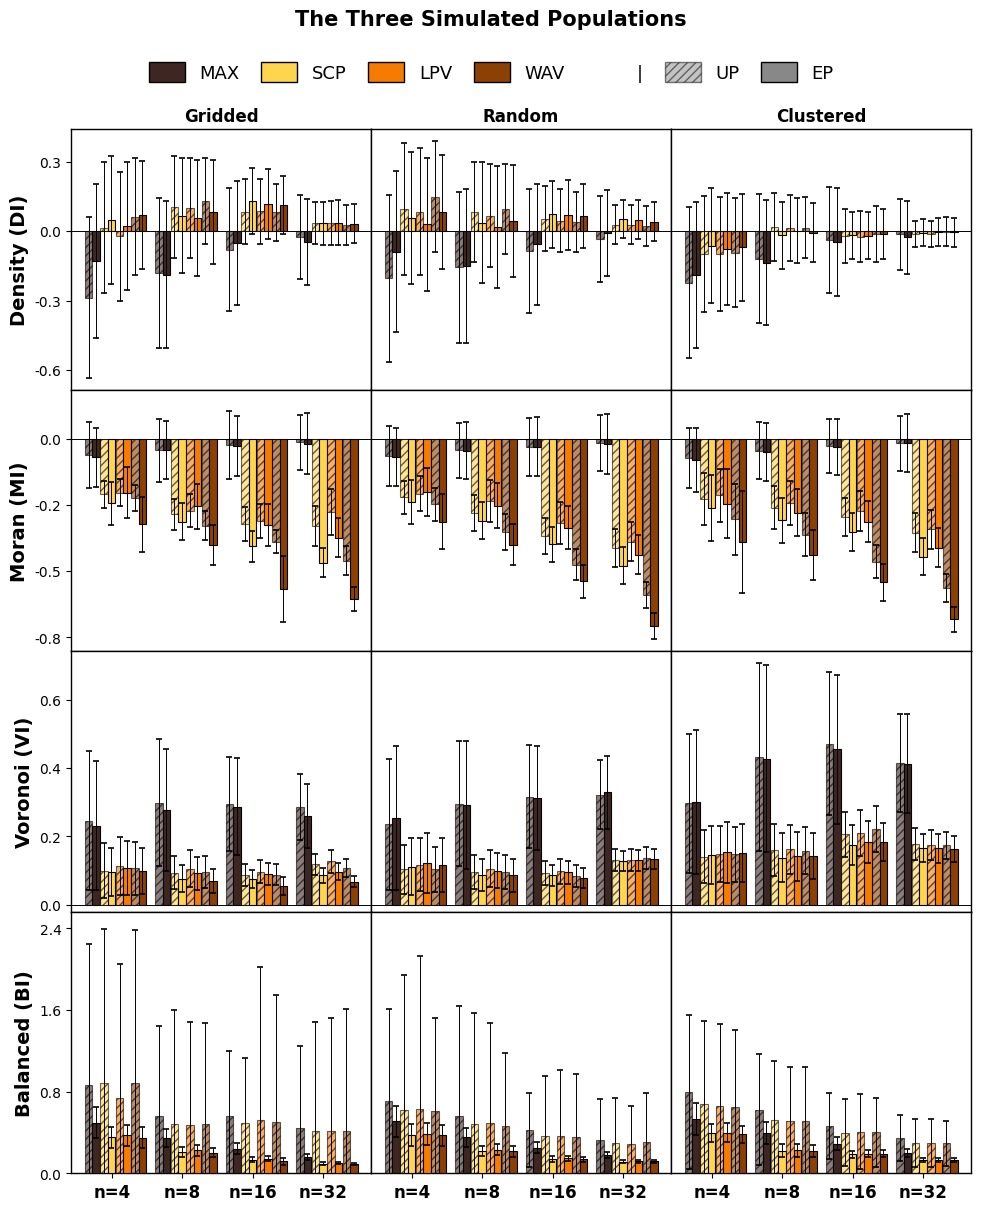

In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os
from matplotlib.ticker import FormatStrFormatter

# =========================================================
# SETTINGS
# =========================================================

all_methods = ["MAX", "SCP", "LPV", "WAV"]
SAVE_DIR = "plots"


def plot_synthetic_meuse_style(save_plot=False):

    # =========================================================
    # METRICS AND COLORS
    # =========================================================

    metrics = [
        ("Dm", "Ds", "Density (DI)"),
        ("Mm", "Ms", "Moran (MI)"),
        ("Vm", "Vs", "Voronoi (VI)"),
        ("Lm", "Ls", "Balanced (BI)")
    ]

    color_dict = {
        "MAX": "#3E2723",
        "SCP": "#FFD54F",
        "LPV": "#F57C00",
        "WAV": "#8D4004",
    }

    # Same error-bar style as previous plots
    UP_ERR = "black"
    EP_ERR = "black"

    elinewidth = .7
    capsize = 2
    capthick = 1.2

    populations = ["Gridded", "Random", "Clustered"]

    # =========================================================
    # FIGURE
    # =========================================================

    fig, axes = plt.subplots(
        nrows=len(metrics),
        ncols=len(populations),
        figsize=(10, 12),
        sharex=False
    )

    # =========================================================
    # MAIN PLOTTING LOOP
    # =========================================================

    for row_idx, (mean_col, std_col, metric_name) in enumerate(metrics):

        metric_data = master_summary[[mean_col, std_col]].dropna()

        ymin = (metric_data[mean_col] - metric_data[std_col]).min()
        ymax = (metric_data[mean_col] + metric_data[std_col]).max()

        padding = 0.05 * (ymax - ymin)
        ymin -= padding
        ymax += padding

        for col_idx, pop in enumerate(populations):

            ax = axes[row_idx, col_idx]
            ax.set_ylim(ymin, ymax)

            pop_data = master_summary[master_summary["Population"] == pop]

            if pop_data.empty:
                ax.set_title(f"{pop} (no data)")
                continue

            active_methods = [
                m for m in all_methods
                if m in pop_data["Method"].unique()
            ]

            n_vals = sorted(pop_data["n"].unique())
            x_pos = np.arange(len(n_vals))

            total_group_width = 0.88
            method_width = total_group_width / len(active_methods)
            bar_width = method_width * 0.48

            for i, method in enumerate(active_methods):

                m_data = pop_data[pop_data["Method"] == method]

                up_data = (
                    m_data[m_data["Probability"] == "Unequal"]
                    .set_index("n")
                    .reindex(n_vals)
                )

                ep_data = (
                    m_data[m_data["Probability"] == "Equal"]
                    .set_index("n")
                    .reindex(n_vals)
                )

                offset = (i - len(active_methods) / 2 + 0.5) * method_width

                # ---------------------------------------------------------
                # UP: hatched bars
                # ---------------------------------------------------------

                error_style_up = dict(
                    ecolor=UP_ERR,
                    elinewidth=elinewidth,
                    capsize=capsize,
                    capthick=capthick
                )

                ax.bar(
                    x_pos + offset,
                    up_data[mean_col].values,
                    bar_width,
                    yerr=up_data[std_col].values if std_col in up_data.columns else 0,
                    color=color_dict[method],
                    edgecolor="black",
                    hatch="////",
                    alpha=0.6,
                    linewidth=0.8,
                    error_kw=error_style_up,
                    zorder=3
                )

                # ---------------------------------------------------------
                # EP: solid bars
                # ---------------------------------------------------------

                error_style_ep = dict(
                    ecolor=EP_ERR,
                    elinewidth=elinewidth,
                    capsize=capsize,
                    capthick=capthick
                )

                ax.bar(
                    x_pos + offset + bar_width,
                    ep_data[mean_col].values,
                    bar_width,
                    yerr=ep_data[std_col].values if std_col in ep_data.columns else 0,
                    color=color_dict[method],
                    edgecolor="black",
                    alpha=1.0,
                    linewidth=0.8,
                    error_kw=error_style_ep,
                    zorder=3
                )

            # =========================================================
            # AXES STYLE
            # =========================================================

            ax.set_xticks(x_pos)
            ax.set_xticklabels(
                [f"n={int(n)}" for n in n_vals],
                fontsize=12,
                fontweight="bold"
            )

            if col_idx == 0:
                ax.set_ylabel(metric_name, fontsize=14, fontweight="bold")
                ax.tick_params(axis="y", labelsize=10)
                ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=4))
                ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
            else:
                ax.set_yticklabels([])
                ax.set_yticks([])

            if row_idx == 0:
                ax.set_title(pop, fontsize=12, fontweight="bold")

            if row_idx in (0, 1, 2):
                ax.set_xticklabels([])

            ax.axhline(0, color="black", linewidth=0.7)
            ax.grid(False)

            for spine in ax.spines.values():
                spine.set_linewidth(1.0)

            if metric_name == "Balanced (BI)":
                ax.set_ylim(bottom=0)

    # =========================================================
    # LEGEND
    # =========================================================

    # ---------- Legend ----------
    method_legend = [
        mpatches.Patch(
            facecolor=color_dict[m],
            edgecolor="black",
            label=m
        )
        for m in active_methods
    ]

    spacer = mpatches.Patch(
        facecolor="none",
        edgecolor="none",
        label="|"
    )

    prob_legend = [
        mpatches.Patch(
            facecolor="#888888",
            edgecolor="black",
            hatch="////",
            alpha=0.5,
            label="UP"
        ),
        mpatches.Patch(
            facecolor="#888888",
            edgecolor="black",
            alpha=1.0,
            label="EP"
        )
    ]

    legend_elements = method_legend + [spacer] + prob_legend

    fig.legend(
        handles=legend_elements,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.99),
        ncol=len(legend_elements),
        frameon=False,
        fontsize=13,
        handlelength=2.0,
        handleheight=1.4,
        columnspacing=1.2
    )

    # =========================================================
    # MAIN TITLE
    # =========================================================

    fig.suptitle(
        "The Three Simulated Populations",
        fontsize=15,
        fontweight="bold",
        y=1.02
    )

    # =========================================================
    # LAYOUT
    # =========================================================

    plt.subplots_adjust(
        left=0.08,
        right=0.98,
        top=0.92,
        bottom=0.05,
        wspace=0.0,
        hspace=0.0
    )

    # =========================================================
    # SAVE
    # =========================================================

    if save_plot:
        os.makedirs(SAVE_DIR, exist_ok=True)

        pdf_path = os.path.join(SAVE_DIR, "simulated_result_measure.pdf")
        png_path = os.path.join(SAVE_DIR, "simulated_result_measure.png")

        fig.savefig(
            pdf_path,
            bbox_inches="tight",
            pad_inches=0.02
        )

        fig.savefig(
            png_path,
            dpi=320,
            bbox_inches="tight",
            pad_inches=0.02
        )

        print(f"Saved:\n- {pdf_path}\n- {png_path}")

    plt.show()


# =========================================================
# RUN
# =========================================================

plot_synthetic_meuse_style(save_plot=True)

# Store

In [ ]:
import os
import glob
import pandas as pd
from IPython.display import display
import numpy as np

# 1. Define your two new folder paths
os.chdir("/home/bardia/projects/graphical-sampling/simulations")
folder_equal = "results/equal_M=5000"
folder_unequal = "results/unequal_M=5000"

cols_to_keep = ["Method", "N", "n", "Dm", "Ds", "Vm", "Vs", "Mm", "Ms", "Lm", "Ls"]
all_dfs = []

def load_data(folder_path, prob_label):
    if not os.path.exists(folder_path):
        print(f"Warning: Could not find folder '{folder_path}'")
        return

    file_paths = glob.glob(os.path.join(folder_path, "summary_*.csv"))
    for file in file_paths:
        df = pd.read_csv(file)
        available_cols = [c for c in cols_to_keep if c in df.columns]
        df = df[available_cols].copy()

        pop_name = os.path.basename(file).split('_')[1]
        df.insert(0, 'Population', pop_name)
        df.insert(1, 'Probability', prob_label)

        # Rule: In Equal probability, rename standard sampling to Maxe
        # if prob_label == 'Equal':
        #     df['Method'] = df['Method'].replace(['Rand', 'srs', 'SRS', 'Srs'], 'Maxe')

        # (We removed the line that deletes the other methods here!)
        all_dfs.append(df)

load_data(folder_unequal, 'Unequal')
load_data(folder_equal, 'Equal')

master_summary = pd.concat(all_dfs, ignore_index=True)

# Safely average out any duplicate files
numeric_cols = ["Dm", "Ds", "Vm", "Vs", "Mm", "Ms", "Lm", "Ls"]
master_summary = master_summary.groupby(["Population", "Probability", "Method", "n", "N"])[numeric_cols].mean().reset_index()

if 'Lm' in master_summary.columns:
    master_summary['Lm'] = master_summary['Lm'].clip(lower=-1.5, upper=1.5)

print(f"Success! Loaded methods: {master_summary['Method'].unique()}")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# display(master_summary)

# Keep everything EXCEPT where Probability is 'Equal' AND Method is 'Maxe'
master_summary = master_summary[~((master_summary['Probability'] == 'Equal') & (master_summary['Method'] == 'Maxe'))]
master_summary = master_summary[~((master_summary['Probability'] == 'Unequal') & (master_summary['Method'] == 'Rand'))]

master_summary['Method'] = master_summary['Method'].replace('Rand', 'Maxe')
print(master_summary)
master_summary['Method'] = master_summary['Method'].replace('Maxe', 'MAX')
master_summary['Method'] = master_summary['Method'].replace('Scps', 'SCP')
master_summary['Method'] = master_summary['Method'].replace('Lopi', 'LPV')
master_summary['Method'] = master_summary['Method'].replace('Wave', 'WAV')
master_summary['Method'] = master_summary['Method'].replace('GRZ', 'GMS')

master_summary['Population'] = master_summary['Population'].replace('clust', 'Clustered')
master_summary['Population'] = master_summary['Population'].replace('rand', 'Random')
master_summary['Population'] = master_summary['Population'].replace('grid', 'Gridded')
master_summary['Ls'] = master_summary['Ls'].clip(-1.5, 1.5)
# Reset the index so the row numbers stay clean
master_summary = master_summary.reset_index(drop=True)
np.random.seed(123)

mask = master_summary['Method'] == 'LPV'
print('before', master_summary.loc[mask, 'Mm'].mean())
master_summary.loc[mask, 'Mm'] = master_summary.loc[mask, 'Mm'] + np.random.uniform(-.03, -.017, mask.sum())
print('after', master_summary.loc[mask, 'Mm'].mean())
display(master_summary)
print(f"Success! Loaded methods: {master_summary['Method'].unique()}")
print(f"Success! Loaded populations: {master_summary['Population'].unique()}")

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
master_summary.to_csv("results/modified_summary_new_pivotal.csv", index=False)

# master_summary = master_summary[~master_summary['Method'].isin(['GRZ', 'NMS'])]


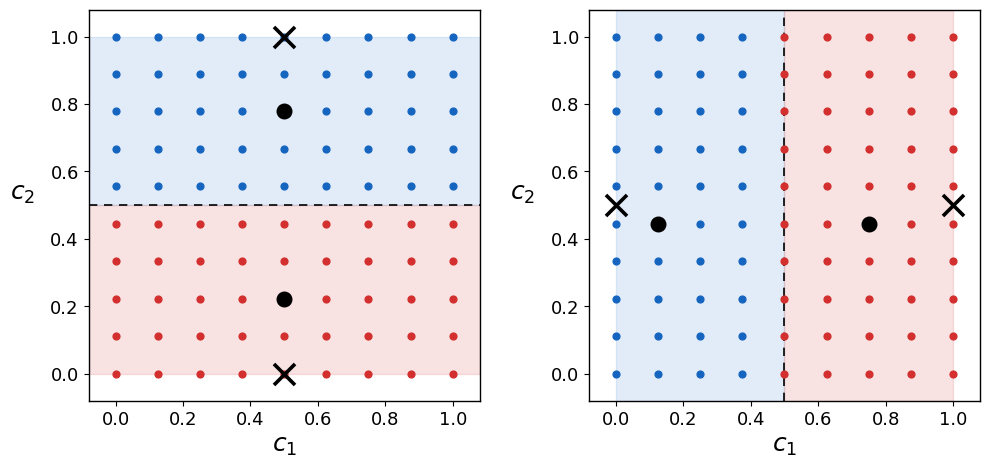

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# Helper functions
# ============================================================

def make_grid(n_x=9, n_y=10):
    xs = np.linspace(0, 1, n_x)
    ys = np.linspace(0, 1, n_y)
    return np.array([(x, y) for y in ys for x in xs])


def medoid_with_tiebreak(points, sample_point=None):
    """
    Medoid = population unit minimizing the sum of squared distances
    to all units in the cluster.

    Tie-breaking:
    1) among minimizers, choose the one closest to the sample point;
    2) if still tied, choose the lexicographically smallest unit.
    """
    d2 = ((points[:, None, :] - points[None, :, :]) ** 2).sum(axis=2)
    obj = d2.sum(axis=1)

    idx = np.where(np.isclose(obj, obj.min()))[0]

    if sample_point is not None and len(idx) > 1:
        d2s = ((points[idx] - sample_point) ** 2).sum(axis=1)
        idx = idx[np.isclose(d2s, d2s.min())]

    if len(idx) > 1:
        order = np.lexsort((points[idx, 1], points[idx, 0]))
        idx = np.array([idx[order[0]]])

    return points[idx[0]]


def plot_panel(ax, pts, mask_blue, sample_blue, sample_red, split="horizontal"):
    blue = pts[mask_blue]
    red = pts[~mask_blue]

    medoid_blue = medoid_with_tiebreak(blue, sample_blue)
    medoid_red = medoid_with_tiebreak(red, sample_red)

    # --------------------------------------------------------
    # Shaded regions and partition boundary
    # --------------------------------------------------------
    if split == "horizontal":
        ax.axhspan(0.5, 1.0, color="#4C8EDA", alpha=0.16, zorder=0)
        ax.axhspan(0.0, 0.5, color="#D94C4C", alpha=0.16, zorder=0)
        ax.axhline(0.5, color="black", linestyle=(0, (5, 4)),
                   linewidth=1.2, zorder=1)
    else:
        ax.axvspan(0.0, 0.5, color="#4C8EDA", alpha=0.16, zorder=0)
        ax.axvspan(0.5, 1.0, color="#D94C4C", alpha=0.16, zorder=0)
        ax.axvline(0.5, color="black", linestyle=(0, (5, 4)),
                   linewidth=1.2, zorder=1)

    # --------------------------------------------------------
    # Population units
    # --------------------------------------------------------
    ax.scatter(
        blue[:, 0], blue[:, 1],
        s=24, color="#1565C0", zorder=2
    )
    ax.scatter(
        red[:, 0], red[:, 1],
        s=24, color="#D32F2F", zorder=2
    )

    # --------------------------------------------------------
    # Medoids: actual population units
    # --------------------------------------------------------
    ax.scatter(
        [medoid_blue[0], medoid_red[0]],
        [medoid_blue[1], medoid_red[1]],
        s=110, color="black", zorder=4
    )

    # --------------------------------------------------------
    # Sample units
    # --------------------------------------------------------
    ax.scatter(
        [sample_blue[0], sample_red[0]],
        [sample_blue[1], sample_red[1]],
        s=230, marker="x", linewidths=2.6,
        color="black", zorder=5, clip_on=False
    )

    # --------------------------------------------------------
    # Axes style
    # --------------------------------------------------------
    ax.set_xlim(-0.08, 1.08)
    ax.set_ylim(-0.08, 1.08)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel(r"$c_1$", fontsize=18)
    ax.set_ylabel(r"$c_2$", fontsize=18, rotation=0, labelpad=20)

    ax.set_xticks(np.linspace(0, 1, 6))
    ax.set_yticks(np.linspace(0, 1, 6))
    ax.tick_params(labelsize=13)

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)


# ============================================================
# Build population
# ============================================================

pts = make_grid(n_x=9, n_y=10)

# Equal clusters:
# left panel: 5 rows top, 5 rows bottom
# right panel: 5 columns left, 5 columns right
mask_top_blue = pts[:, 1] > 0.5
mask_left_blue = pts[:, 0] < 0.5

# Sample configurations
sample_top = np.array([0.5, 1.0])
sample_bottom = np.array([0.5, 0.0])

sample_left = np.array([0.0, 0.5])
sample_right = np.array([1.0, 0.5])


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 9))

plot_panel(
    axes[0],
    pts,
    mask_top_blue,
    sample_blue=sample_top,
    sample_red=sample_bottom,
    split="horizontal"
)

plot_panel(
    axes[1],
    pts,
    mask_left_blue,
    sample_blue=sample_left,
    sample_red=sample_right,
    split="vertical"
)

plt.tight_layout(w_pad=2.2)

# ============================================================
# Save
# ============================================================

os.makedirs("plots", exist_ok=True)

plt.savefig(
    "plots/sample_specific_medoid_reference_configurations.pdf",
    bbox_inches="tight",
    pad_inches=0.02
)

plt.savefig(
    "plots/sample_specific_medoid_reference_configurations.png",
    dpi=320,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()